# 설로인 01 데이터 EDA

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

# from geopy import distance # 거리 계산
# import geopy.distance
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

+ 광고 상호작용이 높은 소재
+ 유입 후 전환 가능성이 높은 소재

## 파워링크 키워드별 데이터

### 데이터 확인

In [2]:
df = pd.read_csv('./dataset/설로인_과제1.xlsx - 파워링크 키워드별.csv', header=1)
df

,Unnamed: 0,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,NaN,SIRLOIN한우,₩ 77,3,1,33.33%,₩ 77,₩ 6,14,"375,011",487027.27%
1,NaN,명절선물한우,₩ 682,9,1,11.11%,₩ 682,₩ 85,8,"325,007",47654.99%
2,NaN,설로인안심,"₩ 3,685",28,6,21.43%,₩ 614,₩ 461,8,"336,007",9118.24%
3,NaN,명절선물,"₩ 231,792","18,616",73,0.39%,"₩ 3,175","₩ 57,948",4,"14,545,516",6275.25%
4,NaN,투뿔등심,"₩ 7,645","2,465",7,0.28%,"₩ 1,092",₩ 695,11,"370,009",4839.88%
...,...,...,...,...,...,...,...,...,...,...,...
375,NaN,설로인이유식,₩ 77,5,1,20.00%,₩ 77,₩ -,-,-,0.00%
376,NaN,설로인후기,₩ 77,2,1,50.00%,₩ 77,₩ -,-,-,0.00%
377,NaN,꽃등심새우살,₩ 77,18,1,5.56%,₩ 77,₩ -,-,-,0.00%
378,NaN,베이비로인,₩ 77,12,1,8.33%,₩ 77,₩ -,-,-,0.00%


In [3]:
# 컬럼명 확인
df.columns

Index(['Unnamed: 0', '키워드', '지출', '노출', '클릭 ', 'CTR', 'CPC', 'CPA', '구매', '매출',
       'ROAS'],
      dtype='object')

In [4]:
# Unnamed 컬럼 삭제
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df.head()

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,SIRLOIN한우,₩ 77,3,1,33.33%,₩ 77,₩ 6,14,"375,011",487027.27%
1,명절선물한우,₩ 682,9,1,11.11%,₩ 682,₩ 85,8,"325,007",47654.99%
2,설로인안심,"₩ 3,685",28,6,21.43%,₩ 614,₩ 461,8,"336,007",9118.24%
3,명절선물,"₩ 231,792","18,616",73,0.39%,"₩ 3,175","₩ 57,948",4,"14,545,516",6275.25%
4,투뿔등심,"₩ 7,645","2,465",7,0.28%,"₩ 1,092",₩ 695,11,"370,009",4839.88%


In [5]:
# 클릭 컬럼명 변경
df.rename(columns={'클릭 ':'클릭'}, inplace=True)

In [6]:
df.shape

(380, 10)

In [7]:
# 결측치 확인
df.isnull().sum()

키워드     0
지출      0
노출      0
클릭      0
CTR     0
CPC     0
CPA     0
구매      0
매출      0
ROAS    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   키워드     380 non-null    object
 1   지출      380 non-null    object
 2   노출      380 non-null    object
 3   클릭      380 non-null    object
 4   CTR     380 non-null    object
 5   CPC     380 non-null    object
 6   CPA     380 non-null    object
 7   구매      380 non-null    object
 8   매출      380 non-null    object
 9   ROAS    380 non-null    object
dtypes: object(10)
memory usage: 29.8+ KB


### 데이터 전처리

+ 키워드를 제외하고 전부 숫자 타입으로 변경 필요
+ CTR, ROAS는 float, 나머지는 int

In [9]:
df

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,SIRLOIN한우,₩ 77,3,1,33.33%,₩ 77,₩ 6,14,"375,011",487027.27%
1,명절선물한우,₩ 682,9,1,11.11%,₩ 682,₩ 85,8,"325,007",47654.99%
2,설로인안심,"₩ 3,685",28,6,21.43%,₩ 614,₩ 461,8,"336,007",9118.24%
3,명절선물,"₩ 231,792","18,616",73,0.39%,"₩ 3,175","₩ 57,948",4,"14,545,516",6275.25%
4,투뿔등심,"₩ 7,645","2,465",7,0.28%,"₩ 1,092",₩ 695,11,"370,009",4839.88%
...,...,...,...,...,...,...,...,...,...,...
375,설로인이유식,₩ 77,5,1,20.00%,₩ 77,₩ -,-,-,0.00%
376,설로인후기,₩ 77,2,1,50.00%,₩ 77,₩ -,-,-,0.00%
377,꽃등심새우살,₩ 77,18,1,5.56%,₩ 77,₩ -,-,-,0.00%
378,베이비로인,₩ 77,12,1,8.33%,₩ 77,₩ -,-,-,0.00%


In [10]:
df.loc[0, '지출'].strip()[2:].replace(',', '')
df.loc[3, '노출'].strip().replace(',', '')
df.loc[379, 'CTR'][:-1]
df.loc[3, 'CPC'].strip()[2:].replace(',', '')
df.loc[377, 'CPA'].strip()[2:].replace(',', '')
df.loc[3, '매출'].strip().replace(',', '')
df.loc[377, 'ROAS'].strip()[:-1]

'0.00'

In [11]:
# 데이터 전처리
for i in df.index:
    df.loc[i, '지출'] = df.loc[i, '지출'].strip()[2:].replace(',', '')
    df.loc[i, '노출'] = df.loc[i, '노출'].strip().replace(',', '')
    df.loc[i, '클릭'] = df.loc[i, '클릭'].strip().replace(',', '')
    df.loc[i, 'CTR'] = df.loc[i, 'CTR'][:-1]
    df.loc[i, 'CPC'] = df.loc[i, 'CPC'].strip()[2:].replace(',', '')
    df.loc[i, 'CPA'] = df.loc[i, 'CPA'].strip()[2:].replace(',', '').replace('-', '0')
    df.loc[i, '구매'] = df.loc[i, '구매'].replace('-', '0')
    df.loc[i, '매출'] = df.loc[i, '매출'].strip().replace(',', '').replace('-', '0')
    df.loc[i, 'ROAS'] = df.loc[i, 'ROAS'].strip()[:-1]

In [12]:
# 데이터 타입 변경
df['CTR'] = df['CTR'].astype('float')
df['ROAS'] = df['ROAS'].astype('float')
df['지출'] = df['지출'].astype('int')
df['노출'] = df['노출'].astype('int')
df['클릭'] = df['클릭'].astype('int')
df['CPC'] = df['CPC'].astype('int')
df['CPA'] = df['CPA'].astype('int')
df['구매'] = df['구매'].astype('int')
df['매출'] = df['매출'].astype('int')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   키워드     380 non-null    object 
 1   지출      380 non-null    int32  
 2   노출      380 non-null    int32  
 3   클릭      380 non-null    int32  
 4   CTR     380 non-null    float64
 5   CPC     380 non-null    int32  
 6   CPA     380 non-null    int32  
 7   구매      380 non-null    int32  
 8   매출      380 non-null    int32  
 9   ROAS    380 non-null    float64
dtypes: float64(2), int32(7), object(1)
memory usage: 19.4+ KB


### 데이터 분석

**효율 소재 단위로 분석하기**

+ 광고 상호작용이 높은 소재
    - 노출, 클릭, 구매
+ 유입 후 전환 가능성이 높은 소재
    - 구매?

In [14]:
df

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,SIRLOIN한우,77,3,1,33.33,77,6,14,375011,487027.27
1,명절선물한우,682,9,1,11.11,682,85,8,325007,47654.99
2,설로인안심,3685,28,6,21.43,614,461,8,336007,9118.24
3,명절선물,231792,18616,73,0.39,3175,57948,4,14545516,6275.25
4,투뿔등심,7645,2465,7,0.28,1092,695,11,370009,4839.88
...,...,...,...,...,...,...,...,...,...,...
375,설로인이유식,77,5,1,20.00,77,0,0,0,0.00
376,설로인후기,77,2,1,50.00,77,0,0,0,0.00
377,꽃등심새우살,77,18,1,5.56,77,0,0,0,0.00
378,베이비로인,77,12,1,8.33,77,0,0,0,0.00


In [15]:
df.describe()

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
count,3.800000e+02,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,3.800000e+02,380.000000
mean,6.309091e+04,2382.263158,25.373684,10.368000,1328.060526,3910.121053,3.105263,1.629724e+05,1531.992947
std,4.913500e+05,8586.703149,109.626025,16.693297,998.910736,15541.069915,20.072283,1.161749e+06,25100.323706
min,7.700000e+01,1.000000,1.000000,0.100000,77.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,1.300750e+03,17.750000,2.000000,1.535000,723.250000,0.000000,0.000000,0.000000e+00,0.000000
50%,6.028000e+03,114.500000,5.000000,4.520000,1070.500000,0.000000,0.000000,0.000000e+00,0.000000
75%,2.291850e+04,1282.500000,18.000000,11.760000,1697.250000,0.000000,0.000000,0.000000e+00,0.000000
max,9.124610e+06,111962.000000,1882.000000,100.000000,7546.000000,198114.000000,351.000000,1.454552e+07,487027.270000


In [16]:
for col in df.columns[1:]:
    print(col)
    print(df[col].sum(), df[col].min(), df[col].max())
    print(df[col].mean(), df[col].median())
    print()

지출
23974544 77 9124610
63090.905263157896 6028.0

노출
905260 1 111962
2382.2631578947367 114.5

클릭
9642 1 1882
25.373684210526317 5.0

CTR
3939.8399999999997 0.1 100.0
10.368 4.52

CPC
504663 77 7546
1328.0605263157895 1070.5

CPA
1485846 0 198114
3910.121052631579 0.0

구매
1180 0 351
3.1052631578947367 0.0

매출
61929527 0 14545516
162972.4394736842 0.0

ROAS
582157.32 0.0 487027.27
1531.99294736842 0.0



In [17]:
# 노출로 정렬
df.sort_values('노출', ascending=False).head(30)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
33,한우,9124610,111962,1882,1.68,4848,25996,351,14026549,153.72
31,스테이크,1219999,61430,728,1.19,1676,36970,33,2723000,223.20
75,생일상차림메뉴,48180,46834,53,0.11,909,0,0,0,0.00
28,한우선물세트,2469720,43924,534,1.22,4625,18294,135,6785230,274.74
46,집들이음식,122892,39786,59,0.15,2083,0,0,0,0.00
34,설선물,594341,39475,182,0.46,3266,198114,3,0,0.00
38,홈파티음식,295966,30899,119,0.39,2487,0,0,0,0.00
55,차돌박이,95084,27287,82,0.30,1160,10565,9,0,0.00
138,스테이크맛있게굽는법,13970,27181,27,0.10,517,0,0,0,0.00
37,설선물세트,332640,26611,168,0.63,1980,0,0,0,0.00


In [18]:
# 클릭으로 정렬
df.sort_values('클릭', ascending=False).head(30)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
33,한우,9124610,111962,1882,1.68,4848,25996,351,14026549,153.72
31,스테이크,1219999,61430,728,1.19,1676,36970,33,2723000,223.20
28,한우선물세트,2469720,43924,534,1.22,4625,18294,135,6785230,274.74
11,선물세트,650254,24550,185,0.75,3515,65025,10,5694556,875.74
34,설선물,594341,39475,182,0.46,3266,198114,3,0,0.00
12,설로인한우,355663,5335,179,3.36,1987,4680,76,2969563,834.94
37,설선물세트,332640,26611,168,0.63,1980,0,0,0,0.00
44,스테이크고기,136642,3251,135,4.15,1012,136642,1,0,0.00
18,1등급한우,336633,7703,128,1.66,2630,37404,9,1987000,590.26
39,소고기선물세트,260238,8527,121,1.42,2151,52048,5,0,0.00


In [19]:
# 클릭 0이상
df[df['클릭']>0]

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,SIRLOIN한우,77,3,1,33.33,77,6,14,375011,487027.27
1,명절선물한우,682,9,1,11.11,682,85,8,325007,47654.99
2,설로인안심,3685,28,6,21.43,614,461,8,336007,9118.24
3,명절선물,231792,18616,73,0.39,3175,57948,4,14545516,6275.25
4,투뿔등심,7645,2465,7,0.28,1092,695,11,370009,4839.88
...,...,...,...,...,...,...,...,...,...,...
375,설로인이유식,77,5,1,20.00,77,0,0,0,0.00
376,설로인후기,77,2,1,50.00,77,0,0,0,0.00
377,꽃등심새우살,77,18,1,5.56,77,0,0,0,0.00
378,베이비로인,77,12,1,8.33,77,0,0,0,0.00


In [20]:
# 클릭 1
df[df['클릭']==1]

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,SIRLOIN한우,77,3,1,33.33,77,6,14,375011,487027.27
1,명절선물한우,682,9,1,11.11,682,85,8,325007,47654.99
190,회사직원선물,6578,10,1,10.00,6578,0,0,0,0.00
196,기업선물,5874,9,1,11.11,5874,0,0,0,0.00
209,기업체선물,4829,5,1,20.00,4829,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...
375,설로인이유식,77,5,1,20.00,77,0,0,0,0.00
376,설로인후기,77,2,1,50.00,77,0,0,0,0.00
377,꽃등심새우살,77,18,1,5.56,77,0,0,0,0.00
378,베이비로인,77,12,1,8.33,77,0,0,0,0.00


In [21]:
# 클릭 10이상
df[df['클릭']>9]

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
3,명절선물,231792,18616,73,0.39,3175,57948,4,14545516,6275.25
5,프리미엄소고기,12397,100,17,17.00,729,443,28,497625,4014.08
6,한우갈비살,39061,2276,19,0.83,2056,4883,8,1541561,3946.55
8,프라임소고기,61138,2544,61,2.40,1002,3596,17,1251651,2047.26
9,한우꽃등심,182622,7869,120,1.52,1522,36524,5,2659845,1456.48
...,...,...,...,...,...,...,...,...,...,...
171,한우등심구이,8085,585,13,2.22,622,0,0,0,0.00
180,이유식한우,7381,176,10,5.68,738,0,0,0,0.00
194,생일상메뉴,5951,2521,12,0.48,496,0,0,0,0.00
216,SIRLOIN,4411,1522,11,0.72,401,1103,4,0,0.00


In [22]:
# 클릭 15이상
df[df['클릭']>5]

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
2,설로인안심,3685,28,6,21.43,614,461,8,336007,9118.24
3,명절선물,231792,18616,73,0.39,3175,57948,4,14545516,6275.25
4,투뿔등심,7645,2465,7,0.28,1092,695,11,370009,4839.88
5,프리미엄소고기,12397,100,17,17.00,729,443,28,497625,4014.08
6,한우갈비살,39061,2276,19,0.83,2056,4883,8,1541561,3946.55
...,...,...,...,...,...,...,...,...,...,...
225,소고기안심가격,3927,130,8,6.15,491,0,0,0,0.00
228,채끝살가격,3806,57,6,10.53,634,0,0,0,0.00
232,스테이크굽기,3619,3646,6,0.16,603,0,0,0,0.00
255,소고기온라인,2255,39,11,28.21,205,1128,2,0,0.00


In [23]:
# 클릭 30이상
df[df['클릭']>29].sort_values('클릭', ascending=False).head(30)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
33,한우,9124610,111962,1882,1.68,4848,25996,351,14026549,153.72
31,스테이크,1219999,61430,728,1.19,1676,36970,33,2723000,223.20
28,한우선물세트,2469720,43924,534,1.22,4625,18294,135,6785230,274.74
11,선물세트,650254,24550,185,0.75,3515,65025,10,5694556,875.74
34,설선물,594341,39475,182,0.46,3266,198114,3,0,0.00
12,설로인한우,355663,5335,179,3.36,1987,4680,76,2969563,834.94
37,설선물세트,332640,26611,168,0.63,1980,0,0,0,0.00
44,스테이크고기,136642,3251,135,4.15,1012,136642,1,0,0.00
18,1등급한우,336633,7703,128,1.66,2630,37404,9,1987000,590.26
39,소고기선물세트,260238,8527,121,1.42,2151,52048,5,0,0.00


In [24]:
df[df['지출']==77]

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,SIRLOIN한우,77,3,1,33.33,77,6,14,375011,487027.27
372,르통샤퀴테리,77,3,1,33.33,77,0,0,0,0.00
373,설로인매장,77,6,1,16.67,77,0,0,0,0.00
374,설로인스테이크,77,7,1,14.29,77,0,0,0,0.00
375,설로인이유식,77,5,1,20.00,77,0,0,0,0.00
376,설로인후기,77,2,1,50.00,77,0,0,0,0.00
377,꽃등심새우살,77,18,1,5.56,77,0,0,0,0.00
378,베이비로인,77,12,1,8.33,77,0,0,0,0.00
379,홈파티고기세트,77,1,1,100.00,77,0,0,0,0.00


+ 클릭수를 몇부터 유의미한 결과로 봐야할까?
+ 구매 0은 제외해도 될까?

#### 클릭 몇부터 유의미?

In [25]:
# 클릭으로 정렬
df[df['구매']==0].sort_values('클릭', ascending=False).head(30)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
37,설선물세트,332640,26611,168,0.63,1980,0,0,0,0.0
38,홈파티음식,295966,30899,119,0.39,2487,0,0,0,0.0
36,명절선물세트,344278,17237,115,0.67,2994,0,0,0,0.0
58,소고기스테이크,84953,5598,91,1.63,934,0,0,0,0.0
52,바베큐,102168,8066,77,0.95,1327,0,0,0,0.0
48,한우1++,113509,3051,76,2.49,1494,0,0,0,0.0
64,채끝살,72864,6876,71,1.03,1026,0,0,0,0.0
45,설선물세트추천,136400,8446,69,0.82,1977,0,0,0,0.0
46,집들이음식,122892,39786,59,0.15,2083,0,0,0,0.0
70,바베큐고기,54725,1552,58,3.74,944,0,0,0,0.0


In [26]:
df[df['클릭']>9]['클릭']

3       73
5       17
6       19
8       61
9      120
      ... 
171     13
180     10
194     12
216     11
255     11
Name: 클릭, Length: 140, dtype: int32

<AxesSubplot:xlabel='클릭', ylabel='Count'>

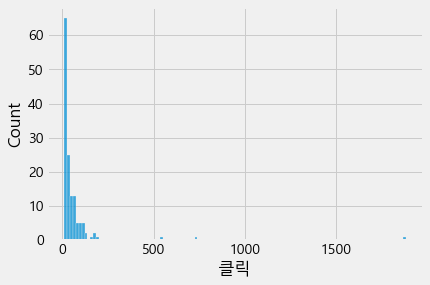

In [27]:
sns.histplot(x=df[df['클릭']>9]['클릭'])

<AxesSubplot:xlabel='노출', ylabel='클릭'>

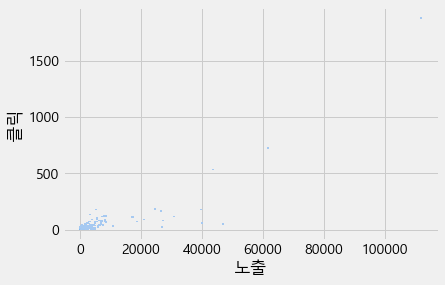

In [28]:
sns.histplot(x=df['노출'], y=df['클릭'])

#### 구매 0 데이터 확인해보기

In [29]:
# 구매 0인 데이터
df[df['구매']==0]

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
36,명절선물세트,344278,17237,115,0.67,2994,0,0,0,0.0
37,설선물세트,332640,26611,168,0.63,1980,0,0,0,0.0
38,홈파티음식,295966,30899,119,0.39,2487,0,0,0,0.0
42,거래처선물,142098,1122,26,2.32,5465,0,0,0,0.0
45,설선물세트추천,136400,8446,69,0.82,1977,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
375,설로인이유식,77,5,1,20.00,77,0,0,0,0.0
376,설로인후기,77,2,1,50.00,77,0,0,0,0.0
377,꽃등심새우살,77,18,1,5.56,77,0,0,0,0.0
378,베이비로인,77,12,1,8.33,77,0,0,0,0.0


#### 키워드 그룹핑

In [30]:
df

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,SIRLOIN한우,77,3,1,33.33,77,6,14,375011,487027.27
1,명절선물한우,682,9,1,11.11,682,85,8,325007,47654.99
2,설로인안심,3685,28,6,21.43,614,461,8,336007,9118.24
3,명절선물,231792,18616,73,0.39,3175,57948,4,14545516,6275.25
4,투뿔등심,7645,2465,7,0.28,1092,695,11,370009,4839.88
...,...,...,...,...,...,...,...,...,...,...
375,설로인이유식,77,5,1,20.00,77,0,0,0,0.00
376,설로인후기,77,2,1,50.00,77,0,0,0,0.00
377,꽃등심새우살,77,18,1,5.56,77,0,0,0,0.00
378,베이비로인,77,12,1,8.33,77,0,0,0,0.00


In [31]:
# 그룹핑 컬럼 생성
df['그룹핑'] = np.nan
df

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,그룹핑
0,SIRLOIN한우,77,3,1,33.33,77,6,14,375011,487027.27,NaN
1,명절선물한우,682,9,1,11.11,682,85,8,325007,47654.99,NaN
2,설로인안심,3685,28,6,21.43,614,461,8,336007,9118.24,NaN
3,명절선물,231792,18616,73,0.39,3175,57948,4,14545516,6275.25,NaN
4,투뿔등심,7645,2465,7,0.28,1092,695,11,370009,4839.88,NaN
...,...,...,...,...,...,...,...,...,...,...,...
375,설로인이유식,77,5,1,20.00,77,0,0,0,0.00,NaN
376,설로인후기,77,2,1,50.00,77,0,0,0,0.00,NaN
377,꽃등심새우살,77,18,1,5.56,77,0,0,0,0.00,NaN
378,베이비로인,77,12,1,8.33,77,0,0,0,0.00,NaN


In [32]:
# 첫 번째
for i in df.index:
    if ('설로인' in df.loc[i, '키워드']) or ('로인' in df.loc[i, '키워드']) or ('SIRLOIN' in df.loc[i, '키워드']) or ('TJFFHDLS' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '브랜드'
    elif ('선물' in df.loc[i, '키워드']) or ('명절' in df.loc[i, '키워드']) or ('설날' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '선물'
    elif ('이유식' in df.loc[i, '키워드']) or ('유아' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '베이비'
    elif ('파티' in df.loc[i, '키워드']) or ('집들이' in df.loc[i, '키워드']) or ('손님' in df.loc[i, '키워드']) or ('잔치' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('생일' in df.loc[i, '키워드']) or ('생신' in df.loc[i, '키워드']) or ('펜션' in df.loc[i, '키워드']) or ('글램핑' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('스테이크' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '스테이크'
    elif ('바베큐' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '바베큐'   
    else:
        df.loc[i, '그룹핑'] = '소고기'

In [33]:
# 그룹별 키워드 개수
df.groupby('그룹핑').count().sort_values('키워드', ascending=False)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,,
소고기,159,159,159,159,159,159,159,159,159,159
선물,104,104,104,104,104,104,104,104,104,104
스테이크,43,43,43,43,43,43,43,43,43,43
특별한날,34,34,34,34,34,34,34,34,34,34
브랜드,16,16,16,16,16,16,16,16,16,16
베이비,15,15,15,15,15,15,15,15,15,15
바베큐,9,9,9,9,9,9,9,9,9,9


In [34]:
df.groupby('그룹핑').sum().sort_values('클릭', ascending=False)

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,
소고기,13408164,350786,4759,1590.40,187929,688994,665,25013327,24831.19
선물,6982602,240360,2272,1014.42,214575,524466,251,28446538,56745.59
스테이크,2029302,131499,1538,586.19,39459,225239,111,4048075,2396.36
특별한날,708356,156620,471,168.53,32980,0,0,0,0.00
브랜드,423973,8649,271,346.56,5092,9155,132,4115602,497726.06
바베큐,290785,12944,220,62.81,11317,6963,1,0,0.00
베이비,131362,4402,111,170.93,13311,31029,20,305985,458.12


##### 두 번째

In [35]:
# 두 번째 스테이크++
for i in df.index:
    if ('설로인' in df.loc[i, '키워드']) or ('로인' in df.loc[i, '키워드']) or ('SIRLOIN' in df.loc[i, '키워드']) or ('TJFFHDLS' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '브랜드'
    elif ('선물' in df.loc[i, '키워드']) or ('명절' in df.loc[i, '키워드']) or ('설날' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '선물'
    elif ('이유식' in df.loc[i, '키워드']) or ('유아' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '베이비'
    elif ('파티' in df.loc[i, '키워드']) or ('집들이' in df.loc[i, '키워드']) or ('손님' in df.loc[i, '키워드']) or ('잔치' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('생일' in df.loc[i, '키워드']) or ('생신' in df.loc[i, '키워드']) or ('펜션' in df.loc[i, '키워드']) or ('글램핑' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('스테이크' in df.loc[i, '키워드']) or ('안심' in df.loc[i, '키워드']) or ('등심' in df.loc[i, '키워드']) or ('채끝' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '스테이크'
    elif ('바베큐' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '바베큐'
    else:
        df.loc[i, '그룹핑'] = '소고기'

In [36]:
# 두 번째
df.groupby('그룹핑').count().sort_values('키워드', ascending=False)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,,
선물,104,104,104,104,104,104,104,104,104,104
스테이크,102,102,102,102,102,102,102,102,102,102
소고기,100,100,100,100,100,100,100,100,100,100
특별한날,34,34,34,34,34,34,34,34,34,34
브랜드,16,16,16,16,16,16,16,16,16,16
베이비,15,15,15,15,15,15,15,15,15,15
바베큐,9,9,9,9,9,9,9,9,9,9


In [37]:
# 두 번째
df.groupby('그룹핑').sum().sort_values('클릭', ascending=False)

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,
소고기,12212937,285459,3847,856.51,128589,523845,592,21662854,18230.39
스테이크,3224529,196826,2450,1320.08,98799,390388,184,7398548,8997.16
선물,6982602,240360,2272,1014.42,214575,524466,251,28446538,56745.59
특별한날,708356,156620,471,168.53,32980,0,0,0,0.00
브랜드,423973,8649,271,346.56,5092,9155,132,4115602,497726.06
바베큐,290785,12944,220,62.81,11317,6963,1,0,0.00
베이비,131362,4402,111,170.93,13311,31029,20,305985,458.12


##### 세 번째

In [38]:
for i in df.index:
    if ('설로인' in df.loc[i, '키워드']) or ('로인' in df.loc[i, '키워드']) or ('SIRLOIN' in df.loc[i, '키워드']) or ('TJFFHDLS' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '브랜드'
    elif ('선물' in df.loc[i, '키워드']) or ('명절' in df.loc[i, '키워드']) or ('설날' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '선물'
    elif ('이유식' in df.loc[i, '키워드']) or ('유아' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '베이비'
    elif ('파티' in df.loc[i, '키워드']) or ('집들이' in df.loc[i, '키워드']) or ('손님' in df.loc[i, '키워드']) or ('잔치' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('생일' in df.loc[i, '키워드']) or ('생신' in df.loc[i, '키워드']) or ('펜션' in df.loc[i, '키워드']) or ('글램핑' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('스테이크' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '스테이크'
    elif ('바베큐' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '바베큐'
    elif ('안심' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '안심'
    elif ('등심' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '등심'
    elif ('채끝' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '채끝'
    else:
        df.loc[i, '그룹핑'] = '소고기'

In [39]:
df.groupby('그룹핑').count().sort_values('키워드', ascending=False)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,,
선물,104,104,104,104,104,104,104,104,104,104
소고기,100,100,100,100,100,100,100,100,100,100
스테이크,43,43,43,43,43,43,43,43,43,43
특별한날,34,34,34,34,34,34,34,34,34,34
등심,30,30,30,30,30,30,30,30,30,30
안심,22,22,22,22,22,22,22,22,22,22
브랜드,16,16,16,16,16,16,16,16,16,16
베이비,15,15,15,15,15,15,15,15,15,15
바베큐,9,9,9,9,9,9,9,9,9,9


In [40]:
df.groupby('그룹핑').sum().sort_values('클릭', ascending=False)

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,
소고기,12212937,285459,3847,856.51,128589,523845,592,21662854,18230.39
선물,6982602,240360,2272,1014.42,214575,524466,251,28446538,56745.59
스테이크,2029302,131499,1538,586.19,39459,225239,111,4048075,2396.36
등심,735328,44412,527,347.41,31002,125029,47,3029854,6296.36
특별한날,708356,156620,471,168.53,32980,0,0,0,0.00
브랜드,423973,8649,271,346.56,5092,9155,132,4115602,497726.06
안심,267267,9590,227,359.06,19348,4787,22,320619,304.44
바베큐,290785,12944,220,62.81,11317,6963,1,0,0.00
채끝,192632,11325,158,27.42,8990,35333,4,0,0.00


##### 네 번째 한우로 그룹핑

In [41]:
# 네 번째
for i in df.index:
    if ('설로인' in df.loc[i, '키워드']) or ('로인' in df.loc[i, '키워드']) or ('SIRLOIN' in df.loc[i, '키워드']) or ('TJFFHDLS' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '브랜드'
    elif ('선물' in df.loc[i, '키워드']) or ('명절' in df.loc[i, '키워드']) or ('설날' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '선물'
    elif ('이유식' in df.loc[i, '키워드']) or ('유아' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '베이비'
    elif ('파티' in df.loc[i, '키워드']) or ('집들이' in df.loc[i, '키워드']) or ('손님' in df.loc[i, '키워드']) or ('잔치' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('생일' in df.loc[i, '키워드']) or ('생신' in df.loc[i, '키워드']) or ('펜션' in df.loc[i, '키워드']) or ('글램핑' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '특별한날'
    elif ('스테이크' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '스테이크'
    elif ('바베큐' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '바베큐'
    elif ('한우' in df.loc[i, '키워드']):
        df.loc[i, '그룹핑'] = '한우'   
    else:
        df.loc[i, '그룹핑'] = '소고기'

In [42]:
df.groupby('그룹핑').count().sort_values('키워드', ascending=False)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,,
선물,104,104,104,104,104,104,104,104,104,104
소고기,91,91,91,91,91,91,91,91,91,91
한우,68,68,68,68,68,68,68,68,68,68
스테이크,43,43,43,43,43,43,43,43,43,43
특별한날,34,34,34,34,34,34,34,34,34,34
브랜드,16,16,16,16,16,16,16,16,16,16
베이비,15,15,15,15,15,15,15,15,15,15
바베큐,9,9,9,9,9,9,9,9,9,9


In [43]:
df.groupby('그룹핑').sum().sort_values('클릭', ascending=False)

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,
한우,11816717,207446,3436,716.79,95554,399517,501,22647018,9457.35
선물,6982602,240360,2272,1014.42,214575,524466,251,28446538,56745.59
스테이크,2029302,131499,1538,586.19,39459,225239,111,4048075,2396.36
소고기,1591447,143340,1323,873.61,92375,289477,164,2366309,15373.84
특별한날,708356,156620,471,168.53,32980,0,0,0,0.00
브랜드,423973,8649,271,346.56,5092,9155,132,4115602,497726.06
바베큐,290785,12944,220,62.81,11317,6963,1,0,0.00
베이비,131362,4402,111,170.93,13311,31029,20,305985,458.12


In [44]:
df[df['키워드']=='이베리코등심']

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,그룹핑
301,이베리코등심,1001,1,1,100.0,1001,0,0,0,0.0,소고기


In [45]:
# 그룹별 키워드 확인
for i in df[df['그룹핑']=='한우'].index:
    print(df.loc[i, '키워드'], end=', ')
print()

한우갈비살, 한우꽃등심, 한우소고기, 한우차돌박이, 1등급한우, 프리미엄한우, 한우구이용, 한우세트, 한우안심, 한우구이, 한우, 한우살치살, 한우가격, 명품한우, 한우1++, 한우쇼핑몰, 한우등심가격, 한우등심, 한우안심가격, 한우국거리, 한우채끝, 한우생갈비, 한우불고기, 구이용한우, 1++한우, 한우모듬구이, 한우고기, 한우당일배송, 한우양지, 한우꼬리, 한우채끝살, 한우갈비세트, 한우모듬, 한우토시살, 무항생제한우, 한우++, 한우구이세트, 한우채끝등심, 한우판매, 한우등심구이, 안심한우, 한우소꼬리, 한우셋트, 한우1+, 국내산한우, 한우꽃등심가격, 한우투뿔등심, 한우꽃갈비살, 한우사이트, 설한우, 설한우세트, 1등급한우등심, 한우유명한곳, 한우등심세트, 한우차돌, 한우투뿔안심, 한우안심세트, 한우늑간살, 한우립아이, 한우암소등심, 한우1등급안심, 한우양지살, 한우알등심, 한우안심200G, 한우1++등심, 한우꽃갈비, 한우우둔살가격, 한우안심슬라이스, 


In [46]:
df[df['키워드'].str.contains('세트')]

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,그룹핑
10,한우구이선물세트,17237,110,8,7.27,2155,4309,4,155003,899.25,선물
11,선물세트,650254,24550,185,0.75,3515,65025,10,5694556,875.74,선물
16,설로인선물세트,58344,1614,51,3.16,1144,2431,24,435021,745.61,브랜드
25,한우세트,241351,7319,77,1.05,3134,10056,24,840000,348.04,한우
28,한우선물세트,2469720,43924,534,1.22,4625,18294,135,6785230,274.74,선물
35,횡성한우선물세트,356862,5713,103,1.80,3465,50980,7,0,0.00,선물
36,명절선물세트,344278,17237,115,0.67,2994,0,0,0,0.00,선물
37,설선물세트,332640,26611,168,0.63,1980,0,0,0,0.00,선물
39,소고기선물세트,260238,8527,121,1.42,2151,52048,5,0,0.00,선물
45,설선물세트추천,136400,8446,69,0.82,1977,0,0,0,0.00,선물


In [47]:
for i in df[df['키워드'].str.contains('한우')].index:
    print(df.loc[i, '키워드'])

SIRLOIN한우
명절선물한우
한우갈비살
한우꽃등심
한우구이선물세트
설로인한우
한우소고기
한우선물
한우차돌박이
1등급한우
프리미엄한우
한우등심스테이크
한우스테이크
한우구이용
한우세트
한우안심
한우선물세트
한우구이
한우
횡성한우선물세트
한우살치살
한우가격
명품한우
한우1++
한우쇼핑몰
한우등심가격
한우등심
한우안심가격
한우국거리
한우채끝
한우생갈비
한우불고기
구이용한우
1++한우
한우모듬구이
한우고기
한우당일배송
한우양지
한우꼬리
한우채끝살
한우갈비세트
한우모듬
설선물한우
한우토시살
무항생제한우
한우++
명품한우선물세트
한우안심스테이크
한우선물셋트
한우구이세트
백화점한우선물세트
한우채끝등심
한우판매
한우등심구이
안심한우
한우설선물세트
한우소꼬리
한우등심선물세트
설선물세트한우
이유식한우
한우셋트
한우설선물
한우1+
국내산한우
설날한우
한우꽃등심가격
한우투뿔등심
한우꽃갈비살
한우명절선물
스테이크용한우
한우사이트
설한우
설한우세트
1등급한우등심
설날한우선물세트
한우유명한곳
한우안심선물세트
한우등심세트
한우차돌
설날한우세트
한우투뿔안심
한우안심세트
한우이유식
한우채끝스테이크
한우꽃등심선물세트
설한우선물세트
한우늑간살
한우립아이
한우암소등심
설한우선물
한우1등급안심
한우명절세트
한우양지살
스테이크한우
한우알등심
한우안심200G
한우1++등심
한우스테이크용
한우꽃갈비
설선물한우세트
한우우둔살가격
한우꽃등심스테이크
한우안심슬라이스


In [48]:
df[df['그룹핑']=='소고기']

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,그룹핑
4,투뿔등심,7645,2465,7,0.28,1092,695,11,370009,4839.88,소고기
5,프리미엄소고기,12397,100,17,17.00,729,443,28,497625,4014.08,소고기
7,르통,2068,94,7,7.45,295,414,5,77004,3723.60,소고기
8,프라임소고기,61138,2544,61,2.40,1002,3596,17,1251651,2047.26,소고기
20,샤퀴테리,13915,4120,34,0.83,409,3479,4,70003,503.08,소고기
...,...,...,...,...,...,...,...,...,...,...,...
360,소고기안심요리,220,142,1,0.70,220,0,0,0,0.00,소고기
361,숯불구이용소고기,220,2,1,50.00,220,0,0,0,0.00,소고기
362,숯불구이고기,165,2,1,50.00,165,0,0,0,0.00,소고기
372,르통샤퀴테리,77,3,1,33.33,77,0,0,0,0.00,소고기


In [49]:
for i in df[df['그룹핑'].isnull()].index:
    print(df.loc[i, '키워드'])

In [50]:
df[df['그룹핑']=='소고기'].sort_values('클릭', ascending=False).head(30)

,키워드,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,그룹핑
43,살치살,141636,20949,91,0.43,1556,70818,2,0,0.00,소고기
55,차돌박이,95084,27287,82,0.30,1160,10565,9,0,0.00,소고기
57,채끝등심,89452,5627,72,1.28,1242,3889,23,0,0.00,소고기
29,샤토브리앙,40667,3484,72,2.07,565,2259,18,100017,245.94,소고기
64,채끝살,72864,6876,71,1.03,1026,0,0,0,0.00,소고기
8,프라임소고기,61138,2544,61,2.40,1002,3596,17,1251651,2047.26,소고기
56,등심,94743,7484,43,0.57,2203,0,0,0,0.00,소고기
71,꽃갈비살,54274,4824,43,0.89,1262,18091,3,0,0.00,소고기
83,소고기구이용,40502,1695,38,2.24,1066,10126,4,0,0.00,소고기
81,구이용소고기,44374,1724,37,2.15,1199,44374,1,0,0.00,소고기


In [51]:
48306090 / 1538
178551318 // 14273 
130245528 // 12735

10227

### 데이터 시각화

In [52]:
# 데이터별 상관관계
df.corr()

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
지출,1.000000,0.788108,0.963440,-0.065152,0.268351,0.184709,0.957547,0.712652,-0.006533
노출,0.788108,1.000000,0.861693,-0.155017,0.274352,0.365055,0.718962,0.629347,-0.013851
클릭,0.963440,0.861693,1.000000,-0.109490,0.269116,0.272029,0.921655,0.706650,-0.011323
CTR,-0.065152,-0.155017,-0.109490,1.000000,-0.248062,-0.123427,-0.062799,-0.072020,0.069682
CPC,0.268351,0.274352,0.269116,-0.248062,1.000000,0.190946,0.238143,0.269914,-0.066772
CPA,0.184709,0.365055,0.272029,-0.123427,0.190946,1.000000,0.122203,0.262171,-0.011263
구매,0.957547,0.718962,0.921655,-0.062799,0.238143,0.122203,1.000000,0.710190,0.031673
매출,0.712652,0.629347,0.706650,-0.072020,0.269914,0.262171,0.710190,1.000000,0.020869
ROAS,-0.006533,-0.013851,-0.011323,0.069682,-0.066772,-0.011263,0.031673,0.020869,1.000000


In [53]:
df['그룹핑'].value_counts().index

Index(['선물', '소고기', '한우', '스테이크', '특별한날', '브랜드', '베이비', '바베큐'], dtype='object')

#### 그룹별 수치 비교

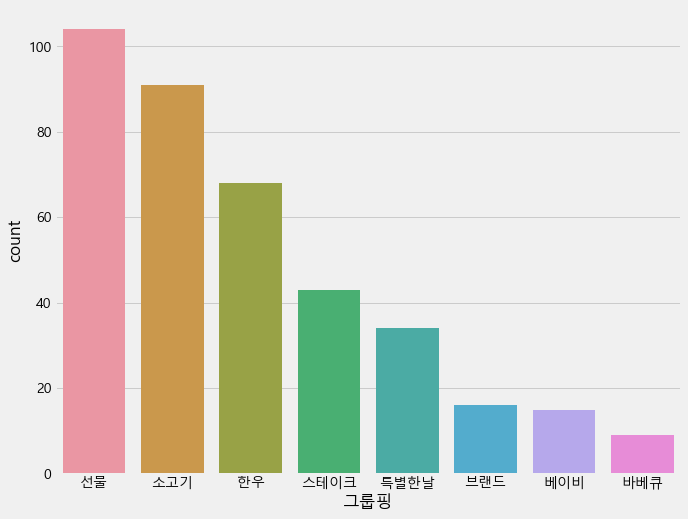

In [54]:
# 그룹별 키워드 개수
plt.figure(figsize=(10, 8))
sns.countplot(df['그룹핑'], order=df['그룹핑'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

In [55]:
df.groupby('그룹핑').sum()

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
그룹핑,,,,,,,,,
바베큐,290785,12944,220,62.81,11317,6963,1,0,0.00
베이비,131362,4402,111,170.93,13311,31029,20,305985,458.12
브랜드,423973,8649,271,346.56,5092,9155,132,4115602,497726.06
선물,6982602,240360,2272,1014.42,214575,524466,251,28446538,56745.59
소고기,1591447,143340,1323,873.61,92375,289477,164,2366309,15373.84
스테이크,2029302,131499,1538,586.19,39459,225239,111,4048075,2396.36
특별한날,708356,156620,471,168.53,32980,0,0,0,0.00
한우,11816717,207446,3436,716.79,95554,399517,501,22647018,9457.35


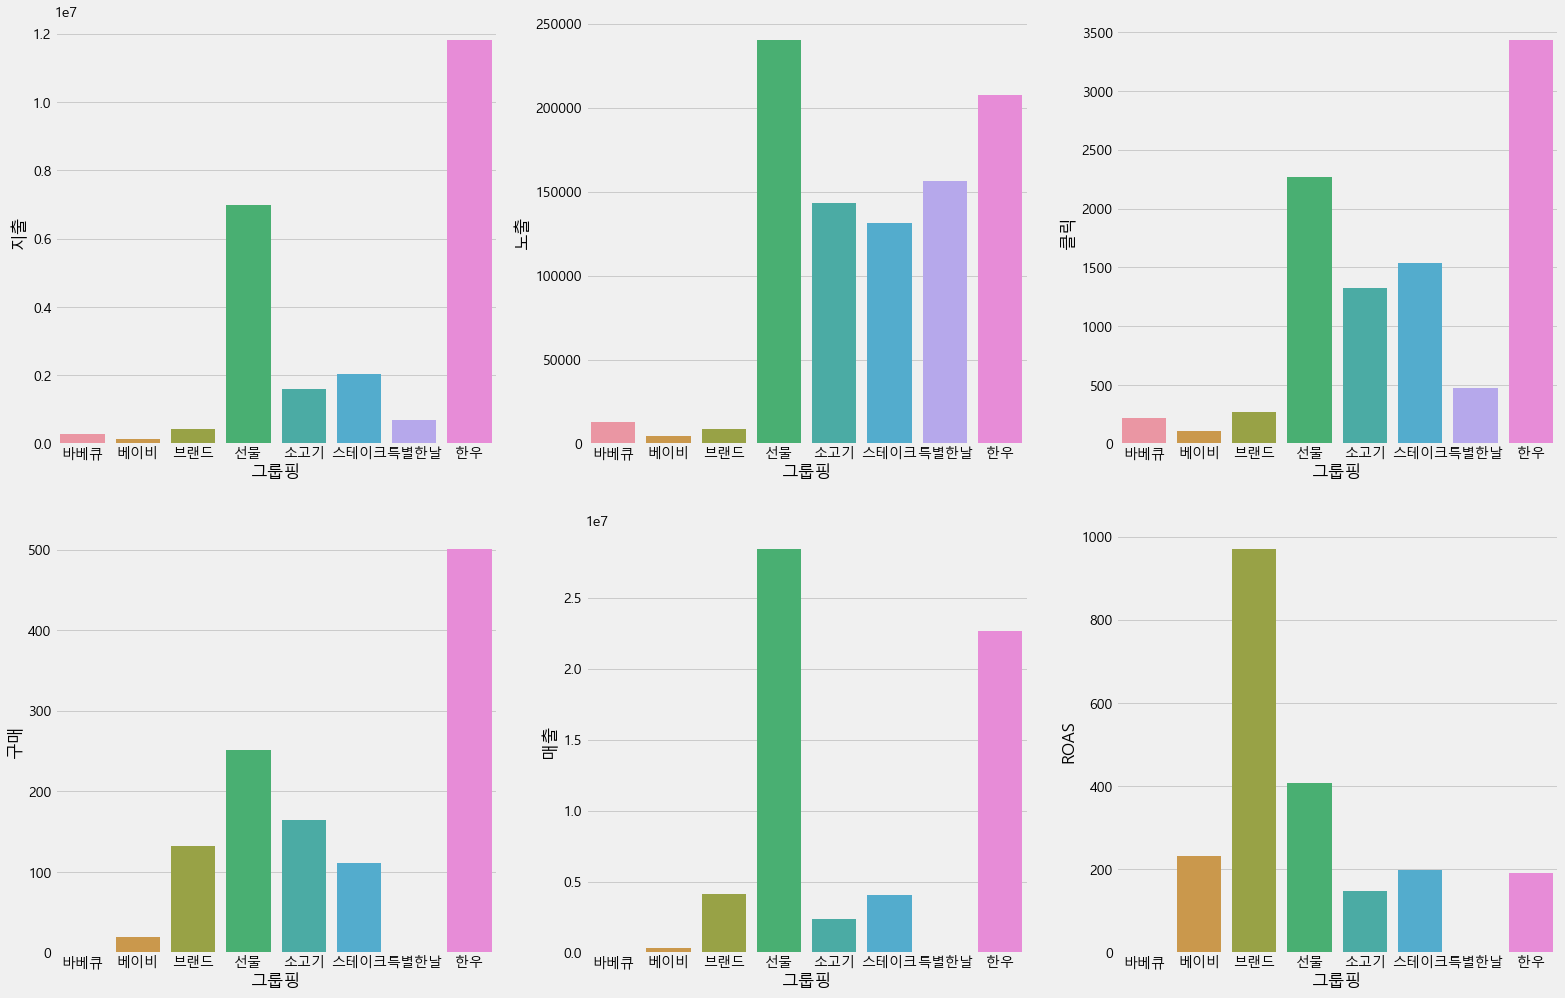

In [56]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 16))
df_by_group_label = df.groupby('그룹핑').sum().reset_index()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
sns.barplot(x='그룹핑', y='지출', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='그룹핑', y='노출', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='그룹핑', y='클릭', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='그룹핑', y='구매', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='그룹핑', y='매출', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='그룹핑', y='ROAS', data=df_by_group_label, ax=axes[1, 2])

plt.show()

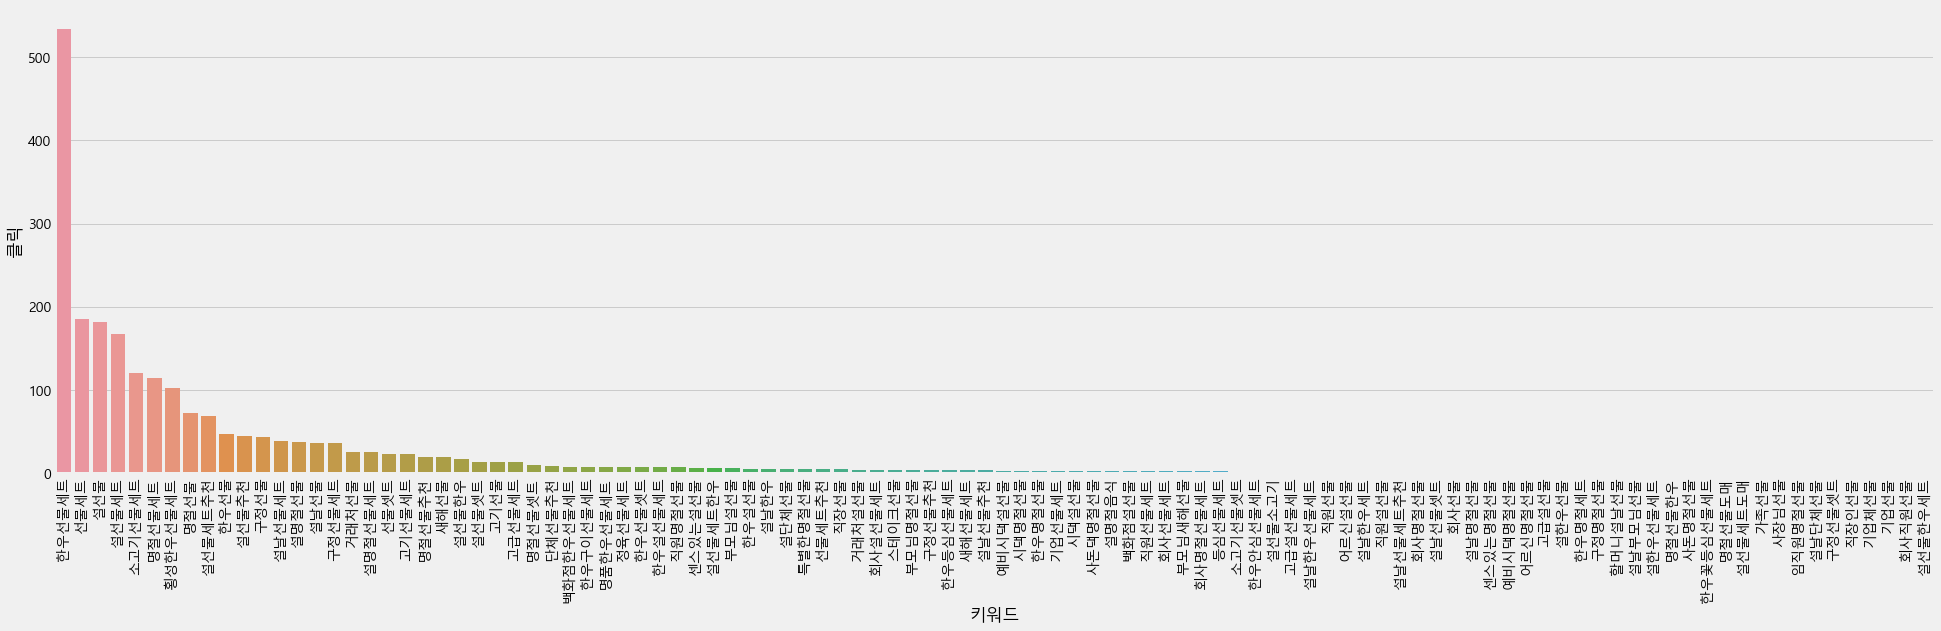

In [57]:
# 그룹별 키워드 수치 확인
df_g1 = df[df['그룹핑']=='선물']
plt.figure(figsize=(30, 8))
sns.barplot(df_g1.sort_values('클릭', ascending=False)['키워드'], df_g1['클릭'])
plt.xticks(rotation=90)
plt.show()

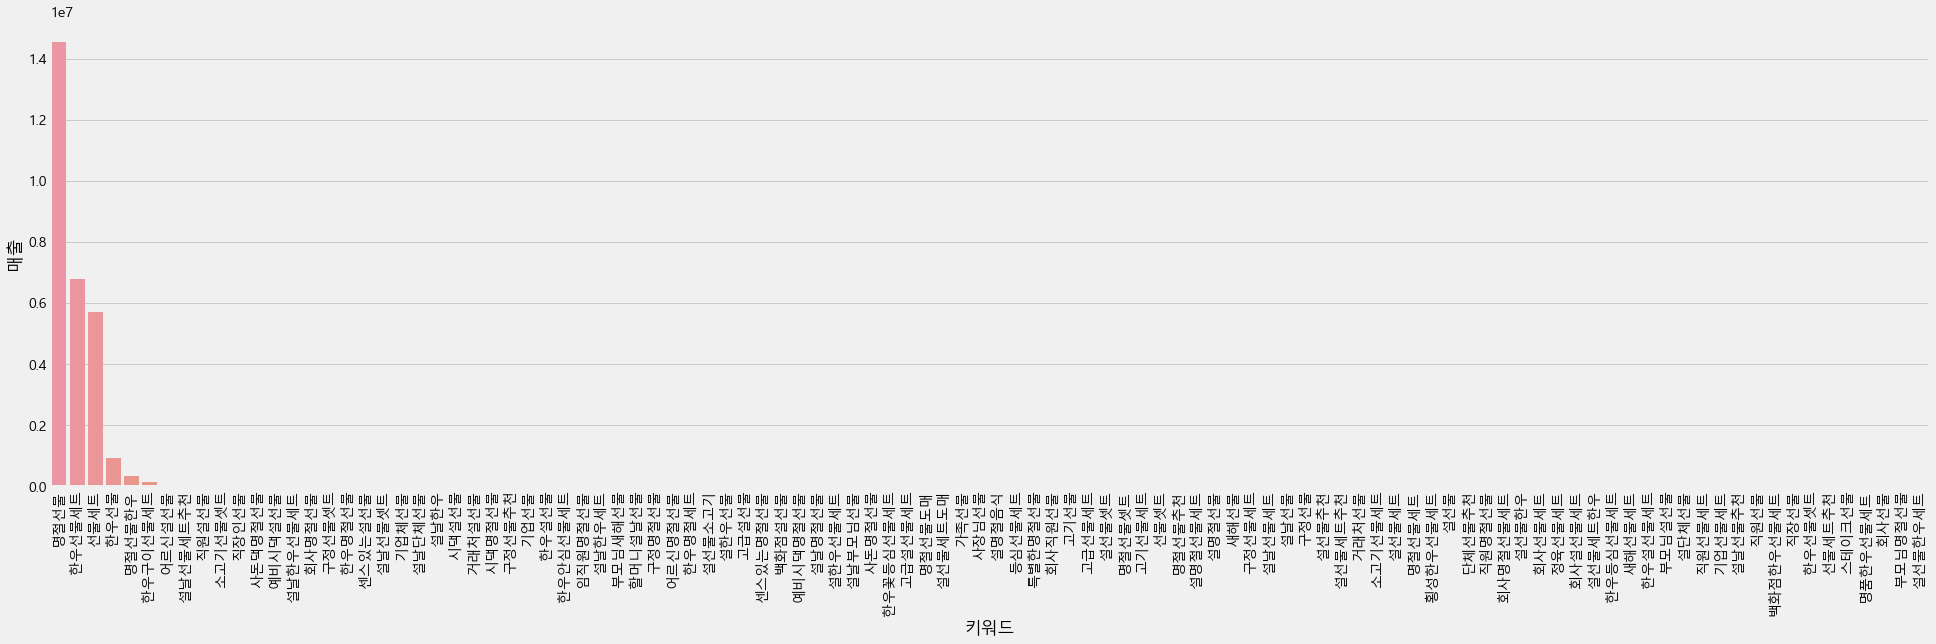

In [58]:
df_g1 = df[df['그룹핑']=='선물']
plt.figure(figsize=(30, 8))
sns.barplot(df_g1.sort_values('매출', ascending=False)['키워드'], df_g1['매출'])
plt.xticks(rotation=90)
plt.show()

## 구글 디스플레이 소재별

### 데이터 확인

In [59]:
df2 = pd.read_csv('./dataset/설로인_과제1.xlsx - 구글 디스플레이 소재별.csv', header=1)
df2

,Unnamed: 0,소재,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,NaN,PC_세트용_728x90(구이랜딩),"₩ 166,148","820,422",166,0.02%,"₩ 1,001","₩ 2,308",72,"₩ 16,536,390",9952.79%
1,NaN,PC_한우구이2차_728x90,"₩ 157,545","837,777",155,0.02%,"₩ 1,016","₩ 2,501",63,"₩ 9,551,200",6062.53%
2,NaN,PC_한우구이2차(미니샤토)_300X600,"₩ 86,923","298,258",151,0.05%,₩ 576,"₩ 6,209",14,"₩ 2,173,000",2499.91%
3,NaN,PC_한우구이2차(고기뒤집는)_300X250,"₩ 141,998","569,490",136,0.02%,"₩ 1,044","₩ 2,958",48,"₩ 11,939,784",8408.39%
4,NaN,PC_한우구이2차(샤토굽는)_120X600,"₩ 93,258","491,059",122,0.02%,₩ 764,"₩ 2,275",41,"₩ 9,378,760",10056.80%
5,NaN,PC_구이용_336x280,"₩ 62,596","185,650",76,0.04%,₩ 824,"₩ 20,865",3,"₩ 515,500",823.54%
6,NaN,PC_한우구이2차(접시에고기)_120X600,"₩ 128,724","500,119",75,0.01%,"₩ 1,716","₩ 1,740",74,"₩ 17,762,302",13798.73%
7,NaN,PC_구이용_120x600,"₩ 72,246","337,208",68,0.02%,"₩ 1,062","₩ 4,014",18,"₩ 2,141,130",2963.68%
8,NaN,PC_한우구이2차(샤토)_300X250,"₩ 69,191","198,900",67,0.03%,"₩ 1,033","₩ 2,232",31,"₩ 5,620,990",8123.85%
9,NaN,PC_한우구이2차(접시위고기)_300X600,"₩ 66,768","219,415",64,0.03%,"₩ 1,043","₩ 5,564",12,"₩ 2,139,860",3204.90%


In [60]:
df2.columns

Index(['Unnamed: 0', '소재', '지출', '노출', '클릭 ', 'CTR', 'CPC', 'CPA', '구매', '매출',
       'ROAS'],
      dtype='object')

In [61]:
# 컬럼 제거
df2 = df2.drop('Unnamed: 0', axis=1)

# 클릭 컬럼명 변경
df2.rename(columns={'클릭 ':'클릭'}, inplace=True)
df2.head()

,소재,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,PC_세트용_728x90(구이랜딩),"₩ 166,148","820,422",166,0.02%,"₩ 1,001","₩ 2,308",72,"₩ 16,536,390",9952.79%
1,PC_한우구이2차_728x90,"₩ 157,545","837,777",155,0.02%,"₩ 1,016","₩ 2,501",63,"₩ 9,551,200",6062.53%
2,PC_한우구이2차(미니샤토)_300X600,"₩ 86,923","298,258",151,0.05%,₩ 576,"₩ 6,209",14,"₩ 2,173,000",2499.91%
3,PC_한우구이2차(고기뒤집는)_300X250,"₩ 141,998","569,490",136,0.02%,"₩ 1,044","₩ 2,958",48,"₩ 11,939,784",8408.39%
4,PC_한우구이2차(샤토굽는)_120X600,"₩ 93,258","491,059",122,0.02%,₩ 764,"₩ 2,275",41,"₩ 9,378,760",10056.80%


+ 전처리 필요
+ 소재 컬럼 모바일, 이름, 크기로 나눠보기.

In [62]:
df2.shape

(22, 10)

In [63]:
df2.isnull().sum()

소재      0
지출      0
노출      0
클릭      0
CTR     0
CPC     0
CPA     0
구매      0
매출      0
ROAS    0
dtype: int64

In [64]:
df2.info() # 구매를 제외한 나머지가 전부 문자열 타입

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   소재      22 non-null     object
 1   지출      22 non-null     object
 2   노출      22 non-null     object
 3   클릭      22 non-null     object
 4   CTR     22 non-null     object
 5   CPC     22 non-null     object
 6   CPA     22 non-null     object
 7   구매      22 non-null     int64 
 8   매출      22 non-null     object
 9   ROAS    22 non-null     object
dtypes: int64(1), object(9)
memory usage: 1.8+ KB


### 데이터 전처리

In [65]:
df2.head()

,소재,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,PC_세트용_728x90(구이랜딩),"₩ 166,148","820,422",166,0.02%,"₩ 1,001","₩ 2,308",72,"₩ 16,536,390",9952.79%
1,PC_한우구이2차_728x90,"₩ 157,545","837,777",155,0.02%,"₩ 1,016","₩ 2,501",63,"₩ 9,551,200",6062.53%
2,PC_한우구이2차(미니샤토)_300X600,"₩ 86,923","298,258",151,0.05%,₩ 576,"₩ 6,209",14,"₩ 2,173,000",2499.91%
3,PC_한우구이2차(고기뒤집는)_300X250,"₩ 141,998","569,490",136,0.02%,"₩ 1,044","₩ 2,958",48,"₩ 11,939,784",8408.39%
4,PC_한우구이2차(샤토굽는)_120X600,"₩ 93,258","491,059",122,0.02%,₩ 764,"₩ 2,275",41,"₩ 9,378,760",10056.80%


In [66]:
df2.loc[4, '매출'][2:]

' 9,378,760 '

In [67]:
# 전처리
for i in df2.index:
    df2.loc[i, '지출'] = df2.loc[i, '지출'].strip()[2:].replace(',', '').replace('-', '0')
    df2.loc[i, '노출'] = df2.loc[i, '노출'].strip().replace(',', '').replace('-', '0')
    df2.loc[i, '클릭'] = df2.loc[i, '클릭'].strip().replace(',', '').replace('-', '0')
    df2.loc[i, 'CTR'] = df2.loc[i, 'CTR'][:-1]
    df2.loc[i, 'CPC'] = df2.loc[i, 'CPC'].strip()[2:].replace(',', '').replace('-', '0')
    df2.loc[i, 'CPA'] = df2.loc[i, 'CPA'].strip()[2:].replace(',', '').replace('-', '0')
    df2.loc[i, '매출'] = df2.loc[i, '매출'].strip()[2:].replace(',', '').replace('-', '0')
    df2.loc[i, 'ROAS'] = df2.loc[i, 'ROAS'].strip()[:-1]

In [68]:
df2.head()

,소재,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,PC_세트용_728x90(구이랜딩),166148,820422,166,0.02,1001,2308,72,16536390,9952.79
1,PC_한우구이2차_728x90,157545,837777,155,0.02,1016,2501,63,9551200,6062.53
2,PC_한우구이2차(미니샤토)_300X600,86923,298258,151,0.05,576,6209,14,2173000,2499.91
3,PC_한우구이2차(고기뒤집는)_300X250,141998,569490,136,0.02,1044,2958,48,11939784,8408.39
4,PC_한우구이2차(샤토굽는)_120X600,93258,491059,122,0.02,764,2275,41,9378760,10056.80


In [69]:
# 데이터 타입 변경
df2['CTR'] = df2['CTR'].astype('float')
df2['ROAS'] = df2['ROAS'].astype('float')
df2['지출'] = df2['지출'].astype('int')
df2['노출'] = df2['노출'].astype('int')
df2['클릭'] = df2['클릭'].astype('int')
df2['CPC'] = df2['CPC'].astype('int')
df2['CPA'] = df2['CPA'].astype('int')
df2['매출'] = df2['매출'].astype('int')

In [70]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   소재      22 non-null     object 
 1   지출      22 non-null     int32  
 2   노출      22 non-null     int32  
 3   클릭      22 non-null     int32  
 4   CTR     22 non-null     float64
 5   CPC     22 non-null     int32  
 6   CPA     22 non-null     int32  
 7   구매      22 non-null     int64  
 8   매출      22 non-null     int32  
 9   ROAS    22 non-null     float64
dtypes: float64(2), int32(6), int64(1), object(1)
memory usage: 1.3+ KB


In [71]:
df2

,소재,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,PC_세트용_728x90(구이랜딩),166148,820422,166,0.02,1001,2308,72,16536390,9952.79
1,PC_한우구이2차_728x90,157545,837777,155,0.02,1016,2501,63,9551200,6062.53
2,PC_한우구이2차(미니샤토)_300X600,86923,298258,151,0.05,576,6209,14,2173000,2499.91
3,PC_한우구이2차(고기뒤집는)_300X250,141998,569490,136,0.02,1044,2958,48,11939784,8408.39
4,PC_한우구이2차(샤토굽는)_120X600,93258,491059,122,0.02,764,2275,41,9378760,10056.80
5,PC_구이용_336x280,62596,185650,76,0.04,824,20865,3,515500,823.54
6,PC_한우구이2차(접시에고기)_120X600,128724,500119,75,0.01,1716,1740,74,17762302,13798.73
7,PC_구이용_120x600,72246,337208,68,0.02,1062,4014,18,2141130,2963.68
8,PC_한우구이2차(샤토)_300X250,69191,198900,67,0.03,1033,2232,31,5620990,8123.85
9,PC_한우구이2차(접시위고기)_300X600,66768,219415,64,0.03,1043,5564,12,2139860,3204.90


#### 컬럼 추가

+ 소재컬럼 나눠보기

In [72]:
df2.iloc[0, 0].split('_')

['PC', '세트용', '728x90(구이랜딩)']

In [73]:
# 소재 컬럼 나누기
for i in df2.index:
    df2.loc[i, 'PC/MO'], df2.loc[i, '소재 이름'], df2.loc[i, '소재 크기'] = df2.loc[i, '소재'].split('_')

df2.head()

,소재,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,PC/MO,소재 이름,소재 크기
0,PC_세트용_728x90(구이랜딩),166148,820422,166,0.02,1001,2308,72,16536390,9952.79,PC,세트용,728x90(구이랜딩)
1,PC_한우구이2차_728x90,157545,837777,155,0.02,1016,2501,63,9551200,6062.53,PC,한우구이2차,728x90
2,PC_한우구이2차(미니샤토)_300X600,86923,298258,151,0.05,576,6209,14,2173000,2499.91,PC,한우구이2차(미니샤토),300X600
3,PC_한우구이2차(고기뒤집는)_300X250,141998,569490,136,0.02,1044,2958,48,11939784,8408.39,PC,한우구이2차(고기뒤집는),300X250
4,PC_한우구이2차(샤토굽는)_120X600,93258,491059,122,0.02,764,2275,41,9378760,10056.80,PC,한우구이2차(샤토굽는),120X600


In [74]:
# 컬럼 순서 변경
df2 = df2[['소재', 'PC/MO', '소재 이름', '소재 크기', '지출', '노출', '클릭', 'CTR', 'CPC', 'CPA', '구매', '매출', 'ROAS']]
df2

,소재,PC/MO,소재 이름,소재 크기,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,PC_세트용_728x90(구이랜딩),PC,세트용,728x90(구이랜딩),166148,820422,166,0.02,1001,2308,72,16536390,9952.79
1,PC_한우구이2차_728x90,PC,한우구이2차,728x90,157545,837777,155,0.02,1016,2501,63,9551200,6062.53
2,PC_한우구이2차(미니샤토)_300X600,PC,한우구이2차(미니샤토),300X600,86923,298258,151,0.05,576,6209,14,2173000,2499.91
3,PC_한우구이2차(고기뒤집는)_300X250,PC,한우구이2차(고기뒤집는),300X250,141998,569490,136,0.02,1044,2958,48,11939784,8408.39
4,PC_한우구이2차(샤토굽는)_120X600,PC,한우구이2차(샤토굽는),120X600,93258,491059,122,0.02,764,2275,41,9378760,10056.80
5,PC_구이용_336x280,PC,구이용,336x280,62596,185650,76,0.04,824,20865,3,515500,823.54
6,PC_한우구이2차(접시에고기)_120X600,PC,한우구이2차(접시에고기),120X600,128724,500119,75,0.01,1716,1740,74,17762302,13798.73
7,PC_구이용_120x600,PC,구이용,120x600,72246,337208,68,0.02,1062,4014,18,2141130,2963.68
8,PC_한우구이2차(샤토)_300X250,PC,한우구이2차(샤토),300X250,69191,198900,67,0.03,1033,2232,31,5620990,8123.85
9,PC_한우구이2차(접시위고기)_300X600,PC,한우구이2차(접시위고기),300X600,66768,219415,64,0.03,1043,5564,12,2139860,3204.90


In [75]:
# 0, 13 인덱스 소재 이름, 소재 크기 데이터 변경해주기
df2.loc[0, '소재 이름'] = '세트용(구이랜딩)'
df2.loc[0, '소재 크기'] = '728X90'
df2.loc[13, '소재 이름'] = '세트용(구이랜딩)'
df2.loc[13, '소재 크기'] = '336X280'
df2.iloc[[0, 13]]

,소재,PC/MO,소재 이름,소재 크기,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,PC_세트용_728x90(구이랜딩),PC,세트용(구이랜딩),728X90,166148,820422,166,0.02,1001,2308,72,16536390,9952.79
13,PC_세트용_336X280(구이랜딩),PC,세트용(구이랜딩),336X280,10640,38240,15,0.04,709,10640,1,123800,1163.56


In [76]:
# 소재 크기 컬럼 X 통일해주기
for i in df2.index:
    df2.loc[i, '소재 크기'] = df2.loc[i, '소재 크기'].replace('x', 'X')

In [77]:
df2['소재 크기'].unique()

array(['728X90', '300X600', '300X250', '120X600', '336X280', '320X100',
       '320X50'], dtype=object)

### 데이터 분석

In [78]:
df2.sum()

소재       PC_세트용_728x90(구이랜딩)PC_한우구이2차_728x90PC_한우구이2차(미...
PC/MO         PCPCPCPCPCPCPCPCPCPCPCPCPCPCMOMOMOMOMOMOMOMO
소재 이름    세트용(구이랜딩)한우구이2차한우구이2차(미니샤토)한우구이2차(고기뒤집는)한우구이2차...
소재 크기    728X90728X90300X600300X250120X600336X280120X60...
지출                                                 2394145
노출                                                11596225
클릭                                                    3899
CTR                                                   0.71
CPC                                                  17139
CPA                                                 106403
구매                                                     964
매출                                               160126642
ROAS                                             116496.82
dtype: object

In [79]:
df2.describe()

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
count,22.000000,2.200000e+01,22.000000,22.000000,22.000000,22.000000,22.000000,2.200000e+01,22.000000
mean,108824.772727,5.271011e+05,177.227273,0.032273,779.045455,4836.500000,43.818182,7.278484e+06,5295.310000
std,103524.426017,6.981291e+05,220.274706,0.024675,435.977116,5173.053549,59.688586,8.751372e+06,3890.370221
min,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,63577.750000,1.889625e+05,54.250000,0.020000,549.500000,1921.250000,7.500000,2.140178e+06,1760.972500
50%,79584.500000,3.261950e+05,99.000000,0.030000,794.000000,2710.000000,27.500000,4.311838e+06,5978.730000
75%,143903.750000,7.095090e+05,163.250000,0.040000,1029.750000,6047.750000,59.250000,9.508090e+06,8120.882500
max,491352.000000,3.378198e+06,854.000000,0.120000,1716.000000,20865.000000,272.000000,3.678765e+07,13798.730000


In [80]:
# 총합, 최소, 최대
for col in df2.columns[4:]:
    print(f'{col}')
    print(f'최소값 : {df2[col].min()}')
    print(f'최대값 : {df2[col].max()}')
    print(df2[col].sum(), df2[col].min(), df2[col].max())
    print()

지출
최소값 : 0
최대값 : 491352
2394145 0 491352

노출
최소값 : 1
최대값 : 3378198
11596225 1 3378198

클릭
최소값 : 0
최대값 : 854
3899 0 854

CTR
최소값 : 0.0
최대값 : 0.12
0.7100000000000002 0.0 0.12

CPC
최소값 : 0
최대값 : 1716
17139 0 1716

CPA
최소값 : 0
최대값 : 20865
106403 0 20865

구매
최소값 : 0
최대값 : 272
964 0 272

매출
최소값 : 0
최대값 : 36787652
160126642 0 36787652

ROAS
최소값 : 0.0
최대값 : 13798.73
116496.82 0.0 13798.73



#### PC 모바일 데이터 나눠서 확인하기


In [81]:
df2_gpm = df2.groupby('PC/MO').sum()
df2_gpm

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
PC/MO,,,,,,,,,
MO,1207324,6614277,2694,0.33,2831,18455,556,74314240,34222.04
PC,1186821,4981948,1205,0.38,14308,87948,408,85812402,82274.78


In [82]:
df2_gpm['ROAS'] = (df2.groupby('PC/MO').sum()['매출'] / df2.groupby('PC/MO').sum()['지출']) * 100
df2_gpm

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
PC/MO,,,,,,,,,
MO,1207324,6614277,2694,0.33,2831,18455,556,74314240,6155.285574
PC,1186821,4981948,1205,0.38,14308,87948,408,85812402,7230.441827


In [83]:
df2_gpm.corr()

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
지출,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0
노출,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0
클릭,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0
CTR,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
CPC,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
CPA,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
구매,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0
매출,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0
ROAS,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0


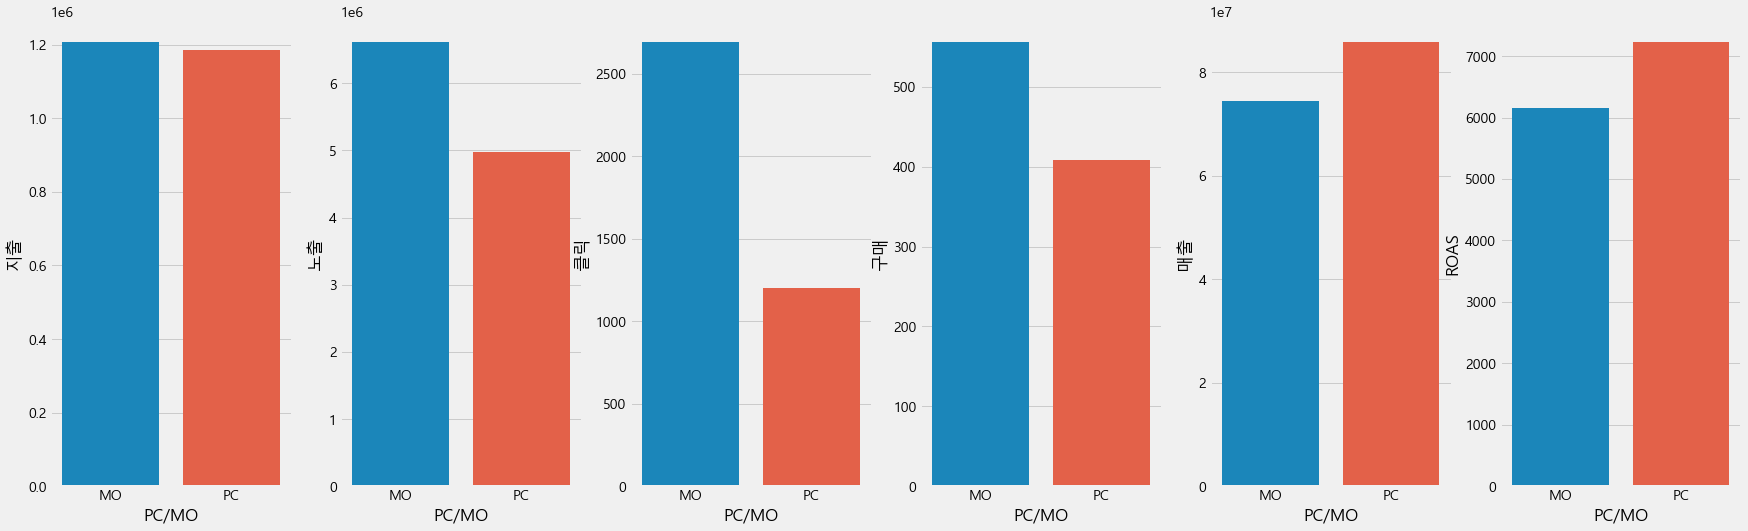

In [84]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(27, 8))
df_by_group_label = df2_gpm.reset_index()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
sns.barplot(x='PC/MO', y='지출', data=df_by_group_label, ax=axes[0])
sns.barplot(x='PC/MO', y='노출', data=df_by_group_label, ax=axes[1])
sns.barplot(x='PC/MO', y='클릭', data=df_by_group_label, ax=axes[2])
sns.barplot(x='PC/MO', y='구매', data=df_by_group_label, ax=axes[3])
sns.barplot(x='PC/MO', y='매출', data=df_by_group_label, ax=axes[4])
sns.barplot(x='PC/MO', y='ROAS', data=df_by_group_label, ax=axes[5])
plt.show()

In [85]:
df_by_group_label = df2_gpm.reset_index()
df_by_group_label

,PC/MO,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
0,MO,1207324,6614277,2694,0.33,2831,18455,556,74314240,6155.285574
1,PC,1186821,4981948,1205,0.38,14308,87948,408,85812402,7230.441827


In [86]:
df_by_group_label = df2.groupby(['PC/MO', '소재 이름']).sum()
df_by_group_label

지출       노출    클릭   CTR   CPC    CPA   구매        매출  \
PC/MO 소재 이름                                                                    
MO    구이용            950365  5458864  2162  0.24  1824  14980  400  51962052   
      한우구이2차(고기뒤집는)  190436   840229   409  0.05   466   1574  121  17857758   
      한우구이2차(샤토단면)    66523   315182   123  0.04   541   1901   35   4494430   
      한우구이2차(샤토마블링)       0        2     0  0.00     0      0    0         0   
PC    구이용            249306   954070   238  0.11  4386  35201   51  10388976   
      세트용(구이랜딩)      176788   858662   181  0.06  1710  12948   73  16660190   
      한우구이2차         173865   891975   171  0.05  2036  18821   64   9748540   
      한우구이2차(고기뒤집는)  141998   569490   136  0.02  1044   2958   48  11939784   
      한우구이2차(미니샤토)    86923   298258   151  0.05   576   6209   14   2173000   
      한우구이2차(샤토)      69191   198900    67  0.03  1033   2232   31   5620990   
      한우구이2차(샤토굽는)    93258   491059   122  0.02   764   2275   41   9378760   
      한우구이2차(접시에고기)  128724   500119    75  0.01  1716   1740   74  17762302   
      한우구이2차(접시위고기)   66768   219415    64  0.03  1043   5564   12   2139860   

                         ROAS  
PC/MO 소재 이름                    
MO    구이용            18088.54  
      한우구이2차(고기뒤집는)   9377.28  
      한우구이2차(샤토단면)    6756.22  
      한우구이2차(샤토마블링)      0.00  
PC    구이용            17794.13  
      세트용(구이랜딩)      11116.35  
      한우구이2차          7271.72  
      한우구이2차(고기뒤집는)   8408.39  
      한우구이2차(미니샤토)    2499.91  
      한우구이2차(샤토)      8123.85  
      한우구이2차(샤토굽는)   10056.80  
      한우구이2차(접시에고기)  13798.73  
      한우구이2차(접시위고기)   3204.90

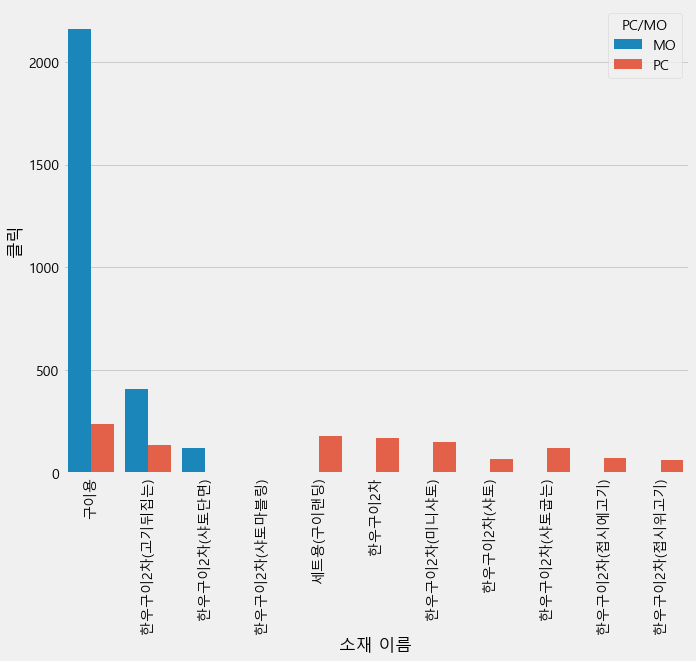

In [87]:
plt.figure(figsize=(10, 8))
df_by_group_label = df2.groupby(['PC/MO', '소재 이름']).sum().reset_index()
sns.barplot(x='소재 이름', y='클릭', hue='PC/MO', data=df_by_group_label )
plt.xticks(rotation=90)
plt.show()

In [88]:
df2.groupby(['PC/MO', '소재 이름', '소재 크기']).sum()

지출       노출   클릭   CTR   CPC    CPA   구매  \
PC/MO 소재 이름         소재 크기                                                   
MO    구이용           300X250  189607   842038  510  0.06   372   4309   44   
                    320X100  491352  3378198  854  0.03   575   1806  272   
                    320X50   124867   756182  196  0.03   637   1982   63   
                    336X280  144539   482446  602  0.12   240   6883   21   
      한우구이2차(고기뒤집는) 300X250       0        1    0  0.00     0      0    0   
                    320X50   190436   840228  409  0.05   466   1574  121   
      한우구이2차(샤토단면)  320X50    66523   315182  123  0.04   541   1901   35   
      한우구이2차(샤토마블링) 300X250       0        2    0  0.00     0      0    0   
PC    구이용           120X600   72246   337208   68  0.02  1062   4014   18   
                    300X250   70047   257831   43  0.02  1629   2919   24   
                    300X600   44417   173381   51  0.03   871   7403    6   
                    336X280   62596   185650   76  0.04   824  20865    3   
      세트용(구이랜딩)     336X280   10640    38240   15  0.04   709  10640    1   
                    728X90   166148   820422  166  0.02  1001   2308   72   
      한우구이2차        336X280   16320    54198   16  0.03  1020  16320    1   
                    728X90   157545   837777  155  0.02  1016   2501   63   
      한우구이2차(고기뒤집는) 300X250  141998   569490  136  0.02  1044   2958   48   
      한우구이2차(미니샤토)  300X600   86923   298258  151  0.05   576   6209   14   
      한우구이2차(샤토)    300X250   69191   198900   67  0.03  1033   2232   31   
      한우구이2차(샤토굽는)  120X600   93258   491059  122  0.02   764   2275   41   
      한우구이2차(접시에고기) 120X600  128724   500119   75  0.01  1716   1740   74   
      한우구이2차(접시위고기) 300X600   66768   219415   64  0.03  1043   5564   12   

                                   매출      ROAS  
PC/MO 소재 이름         소재 크기                        
MO    구이용           300X250   4799160   2531.11  
                    320X100  36787652   7487.03  
                    320X50    8185960   6555.74  
                    336X280   2189280   1514.66  
      한우구이2차(고기뒤집는) 300X250         0      0.00  
                    320X50   17857758   9377.28  
      한우구이2차(샤토단면)  320X50    4494430   6756.22  
      한우구이2차(샤토마블링) 300X250         0      0.00  
PC    구이용           120X600   2141130   2963.68  
                    300X250   4129246   5894.93  
                    300X600   3603100   8111.98  
                    336X280    515500    823.54  
      세트용(구이랜딩)     336X280    123800   1163.56  
                    728X90   16536390   9952.79  
      한우구이2차        336X280    197340   1209.19  
                    728X90    9551200   6062.53  
      한우구이2차(고기뒤집는) 300X250  11939784   8408.39  
      한우구이2차(미니샤토)  300X600   2173000   2499.91  
      한우구이2차(샤토)    300X250   5620990   8123.85  
      한우구이2차(샤토굽는)  120X600   9378760  10056.80  
      한우구이2차(접시에고기) 120X600  17762302  13798.73  
      한우구이2차(접시위고기) 300X600   2139860   3204.90

In [89]:
df2.groupby(['PC/MO', '소재 크기']).sum()

지출       노출   클릭   CTR   CPC    CPA   구매        매출  \
PC/MO 소재 크기                                                             
MO    300X250  189607   842041  510  0.06   372   4309   44   4799160   
      320X100  491352  3378198  854  0.03   575   1806  272  36787652   
      320X50   381826  1911592  728  0.12  1644   5457  219  30538148   
      336X280  144539   482446  602  0.12   240   6883   21   2189280   
PC    120X600  294228  1328386  265  0.05  3542   8029  133  29282192   
      300X250  281236  1026221  246  0.07  3706   8109  103  21690020   
      300X600  198108   691054  266  0.11  2490  19176   32   7915960   
      336X280   89556   278088  107  0.11  2553  47825    5    836640   
      728X90   323693  1658199  321  0.04  2017   4809  135  26087590   

                   ROAS  
PC/MO 소재 크기              
MO    300X250   2531.11  
      320X100   7487.03  
      320X50   22689.24  
      336X280   1514.66  
PC    120X600  26819.21  
      300X250  22427.17  
      300X600  13816.79  
      336X280   3196.29  
      728X90   16015.32

In [90]:
df2['소재 이름'].unique()

array(['세트용(구이랜딩)', '한우구이2차', '한우구이2차(미니샤토)', '한우구이2차(고기뒤집는)',
       '한우구이2차(샤토굽는)', '구이용', '한우구이2차(접시에고기)', '한우구이2차(샤토)',
       '한우구이2차(접시위고기)', '한우구이2차(샤토단면)', '한우구이2차(샤토마블링)'], dtype=object)

## 구글애널리틱스 키워드별

### 데이터 확인

In [91]:
df3 = pd.read_csv('./dataset/설로인_과제1.xlsx - 구글애널리틱스 키워드별_숫자.csv', header=1)
df3

,Unnamed: 0,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매
0,NaN,한우,"1,934","2,100",558,26.57%,3.62,28
1,NaN,한우선물세트,589,630,193,30.63%,4.24,12
2,NaN,설로인한우,184,209,52,24.88%,7.09,8
3,NaN,스테이크,745,777,486,62.55%,3.33,4
4,NaN,한우구이용,60,62,28,45.16%,2.99,4
...,...,...,...,...,...,...,...,...
393,NaN,회사선물,3,3,2,66.67%,3.83,0
394,NaN,회사선물세트,3,3,2,66.67%,1.00,0
395,NaN,회사설선물세트,4,4,3,75.00%,2.21,0
396,NaN,회사직원선물,1,1,1,100.00%,5.50,0


In [92]:
df3.columns

Index(['Unnamed: 0', '키워드', '사용자', '세션', '이탈수', '이탈율', '세션당PV', '구매'], dtype='object')

In [93]:
df3.drop('Unnamed: 0', axis=1, inplace=True)
df3.head()

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매
0,한우,"1,934","2,100",558,26.57%,3.62,28
1,한우선물세트,589,630,193,30.63%,4.24,12
2,설로인한우,184,209,52,24.88%,7.09,8
3,스테이크,745,777,486,62.55%,3.33,4
4,한우구이용,60,62,28,45.16%,2.99,4


In [94]:
df3.tail()

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매
393,회사선물,3,3,2,66.67%,3.83,0
394,회사선물세트,3,3,2,66.67%,1.00,0
395,회사설선물세트,4,4,3,75.00%,2.21,0
396,회사직원선물,1,1,1,100.00%,5.50,0
397,횡성한우선물세트,109,112,51,45.54%,4.00,0


In [95]:
df3.shape

(398, 7)

In [96]:
df3.isnull().sum()

키워드      0
사용자      0
세션       0
이탈수      0
이탈율      0
세션당PV    0
구매       0
dtype: int64

In [97]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   키워드     398 non-null    object 
 1   사용자     398 non-null    object 
 2   세션      398 non-null    object 
 3   이탈수     398 non-null    int64  
 4   이탈율     398 non-null    object 
 5   세션당PV   398 non-null    float64
 6   구매      398 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 21.9+ KB


### 데이터 전처리

In [98]:
df3.head(3)

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매
0,한우,"1,934","2,100",558,26.57%,3.62,28
1,한우선물세트,589,630,193,30.63%,4.24,12
2,설로인한우,184,209,52,24.88%,7.09,8


In [99]:
df3.iloc[0, 4][:-1]

'26.57'

In [100]:
# 데이터 전처리
for i in df3.index:
    df3.loc[i, '사용자'] = df3.loc[i, '사용자'].strip().replace(',', '')
    df3.loc[i, '세션'] = df3.loc[i, '세션'].strip().replace(',', '')
    df3.loc[i, '이탈율'] = df3.loc[i, '이탈율'][:-1]
df3.head()

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매
0,한우,1934,2100,558,26.57,3.62,28
1,한우선물세트,589,630,193,30.63,4.24,12
2,설로인한우,184,209,52,24.88,7.09,8
3,스테이크,745,777,486,62.55,3.33,4
4,한우구이용,60,62,28,45.16,2.99,4


In [101]:
df3.iloc[0, 2]

'2100'

In [102]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   키워드     398 non-null    object 
 1   사용자     398 non-null    object 
 2   세션      398 non-null    object 
 3   이탈수     398 non-null    int64  
 4   이탈율     398 non-null    object 
 5   세션당PV   398 non-null    float64
 6   구매      398 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 21.9+ KB


In [103]:
df3['사용자'] = df3['사용자'].astype('int')
df3['세션'] = df3['세션'].astype('int')
df3['이탈율'] = df3['이탈율'].astype('float')

In [104]:
df3.head(3)

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매
0,한우,1934,2100,558,26.57,3.62,28
1,한우선물세트,589,630,193,30.63,4.24,12
2,설로인한우,184,209,52,24.88,7.09,8


In [105]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   키워드     398 non-null    object 
 1   사용자     398 non-null    int32  
 2   세션      398 non-null    int32  
 3   이탈수     398 non-null    int64  
 4   이탈율     398 non-null    float64
 5   세션당PV   398 non-null    float64
 6   구매      398 non-null    int64  
dtypes: float64(2), int32(2), int64(2), object(1)
memory usage: 18.8+ KB


#### 키워드 그룹핑

In [106]:
# 그룹핑 컬럼 생성
df3['그룹핑'] = np.nan
df3.head()

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매,그룹핑
0,한우,1934,2100,558,26.57,3.62,28,NaN
1,한우선물세트,589,630,193,30.63,4.24,12,NaN
2,설로인한우,184,209,52,24.88,7.09,8,NaN
3,스테이크,745,777,486,62.55,3.33,4,NaN
4,한우구이용,60,62,28,45.16,2.99,4,NaN


In [107]:
# 한우를 포함한 그룹핑
# 네 번째
for i in df3.index:
    if ('설로인' in df3.loc[i, '키워드']) or ('로인' in df3.loc[i, '키워드']) or ('SIRLOIN' in df3.loc[i, '키워드']) or ('TJFFHDLS' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '브랜드'
    elif ('선물' in df3.loc[i, '키워드']) or ('명절' in df3.loc[i, '키워드']) or ('설날' in df3.loc[i, '키워드']) or ('설' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '선물'
    elif ('이유식' in df3.loc[i, '키워드']) or ('유아' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '베이비'
    elif ('파티' in df3.loc[i, '키워드']) or ('집들이' in df3.loc[i, '키워드']) or ('손님' in df3.loc[i, '키워드']) or ('잔치' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '특별한날'
    elif ('생일' in df3.loc[i, '키워드']) or ('생신' in df3.loc[i, '키워드']) or ('펜션' in df3.loc[i, '키워드']) or ('글램핑' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '특별한날'
    elif ('스테이크' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '스테이크'
    elif ('바베큐' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '바베큐'
    elif ('한우' in df3.loc[i, '키워드']):
        df3.loc[i, '그룹핑'] = '한우'   
    else:
        df3.loc[i, '그룹핑'] = '소고기'

In [108]:
df3.isnull().sum()

키워드      0
사용자      0
세션       0
이탈수      0
이탈율      0
세션당PV    0
구매       0
그룹핑      0
dtype: int64

In [109]:
df3.groupby('그룹핑').count().sort_values('키워드', ascending=False)

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매
그룹핑,,,,,,,
선물,110,110,110,110,110,110,110
소고기,96,96,96,96,96,96,96
한우,68,68,68,68,68,68,68
스테이크,43,43,43,43,43,43,43
특별한날,34,34,34,34,34,34,34
브랜드,20,20,20,20,20,20,20
베이비,18,18,18,18,18,18,18
바베큐,9,9,9,9,9,9,9


In [110]:
df3.groupby('그룹핑').sum().sort_values('세션', ascending=False)

,사용자,세션,이탈수,이탈율,세션당PV,구매
그룹핑,,,,,,
한우,3527,3783,1359,3360.10,190.29,43
선물,2434,2513,1344,6372.38,300.71,18
스테이크,1573,1632,943,2232.88,107.63,10
소고기,1364,1418,724,5424.52,319.48,10
특별한날,477,483,408,2793.34,97.04,0
브랜드,288,331,82,558.63,42.85,9
바베큐,217,222,163,551.76,17.08,0
베이비,119,124,48,499.08,103.18,3


In [111]:
# 그룹별 키워드 확인
for i in df3[df3['그룹핑']=='한우'].index:
    print(df3.loc[i, '키워드'], end=', ')
print()
print()
for i in df3[df3['그룹핑']=='선물'].index:
    print(df3.loc[i, '키워드'], end=', ')

한우, 한우구이용, 한우소고기, 한우안심, 1등급한우, 프리미엄한우, 한우갈비살, 한우구이, 한우꽃등심, 한우당일배송, 한우세트, 1++한우, 1등급한우등심, 고급한우세트, 구이용한우, 국내산한우, 명품한우, 명품한우세트, 무항생제한우, 살치살한우, 안심한우, 한우++, 한우1+, 한우1++, 한우1++등심, 한우1등급안심, 한우가격, 한우갈비세트, 한우고기, 한우구이세트, 한우국거리, 한우국거리부위, 한우꼬리, 한우꽃갈비, 한우꽃갈비살, 한우꽃등심가격, 한우늑간살, 한우등심, 한우등심가격, 한우등심구이, 한우등심세트, 한우립아이, 한우모듬, 한우모듬구이, 한우불고기, 한우사이트, 한우살치살, 한우생갈비, 한우셋트, 한우소꼬리, 한우쇼핑몰, 한우안심가격, 한우안심세트, 한우안심슬라이스, 한우알등심, 한우암소등심, 한우양지, 한우우둔살가격, 한우유명한곳, 한우차돌, 한우차돌박이, 한우채끝, 한우채끝등심, 한우채끝살, 한우토시살, 한우투뿔등심, 한우투뿔안심, 한우판매, 

한우선물세트, 한우선물, 명절선물, 명절선물한우, 설선물소고기, 한우구이선물세트, 20만원대선물, 가족선물, 거래처선물, 거래처설선물, 고급선물세트, 고급설선물, 고급설선물세트, 고기선물, 고기선물세트, 구정명절선물, 구정선물, 구정선물세트, 구정선물셋트, 구정선물추천, 기업선물, 기업선물세트, 기업체선물, 단체선물추천, 등심선물세트, 명절선물도매, 명절선물세트, 명절선물셋트, 명절선물추천, 명품한우선물세트, 백화점설선물, 백화점한우선물세트, 부모님명절선물, 부모님새해선물, 부모님설선물, 사돈댁명절선물, 사돈명절선물, 사장님선물, 새해선물, 새해선물세트, 선물세트, 선물세트추천, 선물셋트, 설날단체선물, 설날명절선물, 설날부모님선물, 설날선물, 설날선물세트, 설날선물세트추천, 설날선물셋트, 설날선물추천, 설날한우, 설날한우선물세트, 설날한우세트, 설단체선물, 설명절선물, 설명절선물세트, 설명절음식, 설선물, 설선물세트, 설선물세트도매, 설선물세트추천, 설선물세트한우, 설선물셋트, 설선물추천, 설

In [112]:
df3[df3['그룹핑']=='소고기'].head(30)

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매,그룹핑
6,프리미엄소고기,19,21,5,23.81,4.42,3,소고기
8,프라임소고기,65,68,29,42.65,5.83,2,소고기
13,르통,8,8,1,12.50,4.45,1,소고기
16,샤퀴테리,33,34,11,32.35,5.42,1,소고기
17,샤토브리앙,72,76,36,47.37,1.74,1,소고기
21,차돌박이,81,83,51,61.45,4.61,1,소고기
22,채끝등심,78,88,22,25.00,2.47,1,소고기
33,1++등심,4,4,1,25.00,1.50,0,소고기
34,1++살치살,1,1,0,0.00,5.12,0,소고기
35,1++안심,2,2,0,0.00,2.43,0,소고기


### 데이터 분석

In [113]:
df3.columns

Index(['키워드', '사용자', '세션', '이탈수', '이탈율', '세션당PV', '구매', '그룹핑'], dtype='object')

In [114]:
# 총합, 최소, 최대
for col in df3.columns[1:6]:
    print(col)
    print(df3[col].sum(), df3[col].min(), df3[col].max())
    print(df3[col].mean(), df3[col].median())
    print()

사용자
9999 1 1934
25.123115577889447 4.0

세션
10506 1 2100
26.396984924623116 5.0

이탈수
5071 0 558
12.741206030150753 2.0

이탈율
21792.69 0.0 100.0
54.75550251256282 55.615

세션당PV
1178.2599999999998 1.0 43.0
2.960452261306532 2.0



In [115]:
df3.head(30)

,키워드,사용자,세션,이탈수,이탈율,세션당PV,구매,그룹핑
0,한우,1934,2100,558,26.57,3.62,28,한우
1,한우선물세트,589,630,193,30.63,4.24,12,선물
2,설로인한우,184,209,52,24.88,7.09,8,브랜드
3,스테이크,745,777,486,62.55,3.33,4,스테이크
4,한우구이용,60,62,28,45.16,2.99,4,한우
5,이유식소고기,60,63,27,42.86,13.07,3,베이비
6,프리미엄소고기,19,21,5,23.81,4.42,3,소고기
7,스테이크용소고기,58,60,28,46.67,4.67,2,스테이크
8,프라임소고기,65,68,29,42.65,5.83,2,소고기
9,한우선물,51,55,12,21.82,3.11,2,선물


## 구글애널리틱스 구글 디스플레이 소재별

### 데이터 확인

In [116]:
df4 = pd.read_csv('./dataset/설로인_과제1.xlsx - 구글애널리틱스 구글 디스플레이 소재별.csv', header=1)
df4

,Unnamed: 0,소재,사용자,세션,이탈수,이탈율,세션당PV
0,NaN,PC_120X600_일상속미식경험_샤토굽는,52,51,43,84.3%,1.20
1,NaN,PC_120X600_일상속미식경험_접시에고기,25,26,19,73.1%,2.08
2,NaN,PC_300X250_일상속미식_고기뒤집는,142,142,103,72.5%,1.84
3,NaN,PC_300X250_일상속미식_샤토칼로써는,57,58,41,70.7%,2.14
4,NaN,PC_300X600_일상을특별하게_미니샤토접시,122,120,87,72.5%,1.99
5,NaN,PC_300X600_일상을특별하게_접시위고기,61,62,42,67.7%,2.61
6,NaN,PC_336X280_한우로즐기는_홈파티패키지,12,12,7,58.3%,1.50
7,NaN,PC_728x90_일상속미식_접시위고기,105,106,87,82.1%,1.83
8,NaN,MO_구이용_120x100,375,387,308,79.6%,1.67
9,NaN,MO_구이용_120x600,38,38,28,73.7%,1.64


In [117]:
df4.columns

Index(['Unnamed: 0', '소재', '사용자', '세션', '이탈수', '이탈율', '세션당PV'], dtype='object')

In [118]:
# 컬럼 삭제하기
df4.drop('Unnamed: 0', axis=1, inplace=True)

In [119]:
df4.head()

,소재,사용자,세션,이탈수,이탈율,세션당PV
0,PC_120X600_일상속미식경험_샤토굽는,52,51,43,84.3%,1.20
1,PC_120X600_일상속미식경험_접시에고기,25,26,19,73.1%,2.08
2,PC_300X250_일상속미식_고기뒤집는,142,142,103,72.5%,1.84
3,PC_300X250_일상속미식_샤토칼로써는,57,58,41,70.7%,2.14
4,PC_300X600_일상을특별하게_미니샤토접시,122,120,87,72.5%,1.99


In [120]:
df4.shape

(17, 6)

In [121]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   소재      17 non-null     object 
 1   사용자     17 non-null     int64  
 2   세션      17 non-null     int64  
 3   이탈수     17 non-null     int64  
 4   이탈율     17 non-null     object 
 5   세션당PV   17 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 944.0+ bytes


### 데이터 전처리

#### 데이터 타입 변경

In [122]:
for i in df4.index:
    df4.loc[i, '이탈율'] = df4.loc[i, '이탈율'][:-1]
df4['이탈율'] = df4['이탈율'].astype('float')

In [123]:
df4

,소재,사용자,세션,이탈수,이탈율,세션당PV
0,PC_120X600_일상속미식경험_샤토굽는,52,51,43,84.3,1.20
1,PC_120X600_일상속미식경험_접시에고기,25,26,19,73.1,2.08
2,PC_300X250_일상속미식_고기뒤집는,142,142,103,72.5,1.84
3,PC_300X250_일상속미식_샤토칼로써는,57,58,41,70.7,2.14
4,PC_300X600_일상을특별하게_미니샤토접시,122,120,87,72.5,1.99
5,PC_300X600_일상을특별하게_접시위고기,61,62,42,67.7,2.61
6,PC_336X280_한우로즐기는_홈파티패키지,12,12,7,58.3,1.50
7,PC_728x90_일상속미식_접시위고기,105,106,87,82.1,1.83
8,MO_구이용_120x100,375,387,308,79.6,1.67
9,MO_구이용_120x600,38,38,28,73.7,1.64


In [124]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   소재      17 non-null     object 
 1   사용자     17 non-null     int64  
 2   세션      17 non-null     int64  
 3   이탈수     17 non-null     int64  
 4   이탈율     17 non-null     float64
 5   세션당PV   17 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 944.0+ bytes


#### 컬럼 추가

+ 소재 컬럼 나눠주기

In [125]:
df4.iloc[0, 0].split('_')[:3]

['PC', '120X600', '일상속미식경험']

In [126]:
df4

,소재,사용자,세션,이탈수,이탈율,세션당PV
0,PC_120X600_일상속미식경험_샤토굽는,52,51,43,84.3,1.20
1,PC_120X600_일상속미식경험_접시에고기,25,26,19,73.1,2.08
2,PC_300X250_일상속미식_고기뒤집는,142,142,103,72.5,1.84
3,PC_300X250_일상속미식_샤토칼로써는,57,58,41,70.7,2.14
4,PC_300X600_일상을특별하게_미니샤토접시,122,120,87,72.5,1.99
5,PC_300X600_일상을특별하게_접시위고기,61,62,42,67.7,2.61
6,PC_336X280_한우로즐기는_홈파티패키지,12,12,7,58.3,1.50
7,PC_728x90_일상속미식_접시위고기,105,106,87,82.1,1.83
8,MO_구이용_120x100,375,387,308,79.6,1.67
9,MO_구이용_120x600,38,38,28,73.7,1.64


In [127]:
for i in df4.index:
    df4.loc[i, 'PC/MO'] = df4.loc[i, '소재'].split('_')[0]
    df4.loc[i, '소재 크기'] = df4.loc[i, '소재'].split('_')[1]
    df4.loc[i, '캠페인'] = df4.loc[i, '소재'].split('_')[2]
df4

,소재,사용자,세션,이탈수,이탈율,세션당PV,PC/MO,소재 크기,캠페인
0,PC_120X600_일상속미식경험_샤토굽는,52,51,43,84.3,1.20,PC,120X600,일상속미식경험
1,PC_120X600_일상속미식경험_접시에고기,25,26,19,73.1,2.08,PC,120X600,일상속미식경험
2,PC_300X250_일상속미식_고기뒤집는,142,142,103,72.5,1.84,PC,300X250,일상속미식
3,PC_300X250_일상속미식_샤토칼로써는,57,58,41,70.7,2.14,PC,300X250,일상속미식
4,PC_300X600_일상을특별하게_미니샤토접시,122,120,87,72.5,1.99,PC,300X600,일상을특별하게
5,PC_300X600_일상을특별하게_접시위고기,61,62,42,67.7,2.61,PC,300X600,일상을특별하게
6,PC_336X280_한우로즐기는_홈파티패키지,12,12,7,58.3,1.50,PC,336X280,한우로즐기는
7,PC_728x90_일상속미식_접시위고기,105,106,87,82.1,1.83,PC,728x90,일상속미식
8,MO_구이용_120x100,375,387,308,79.6,1.67,MO,구이용,120x100
9,MO_구이용_120x600,38,38,28,73.7,1.64,MO,구이용,120x600


In [128]:
df4.loc[8:14, '소재 크기'] = df4.loc[8:14, '캠페인']
df4.loc[8:14, '캠페인'] = '구이용'
df4

,소재,사용자,세션,이탈수,이탈율,세션당PV,PC/MO,소재 크기,캠페인
0,PC_120X600_일상속미식경험_샤토굽는,52,51,43,84.3,1.20,PC,120X600,일상속미식경험
1,PC_120X600_일상속미식경험_접시에고기,25,26,19,73.1,2.08,PC,120X600,일상속미식경험
2,PC_300X250_일상속미식_고기뒤집는,142,142,103,72.5,1.84,PC,300X250,일상속미식
3,PC_300X250_일상속미식_샤토칼로써는,57,58,41,70.7,2.14,PC,300X250,일상속미식
4,PC_300X600_일상을특별하게_미니샤토접시,122,120,87,72.5,1.99,PC,300X600,일상을특별하게
5,PC_300X600_일상을특별하게_접시위고기,61,62,42,67.7,2.61,PC,300X600,일상을특별하게
6,PC_336X280_한우로즐기는_홈파티패키지,12,12,7,58.3,1.50,PC,336X280,한우로즐기는
7,PC_728x90_일상속미식_접시위고기,105,106,87,82.1,1.83,PC,728x90,일상속미식
8,MO_구이용_120x100,375,387,308,79.6,1.67,MO,120x100,구이용
9,MO_구이용_120x600,38,38,28,73.7,1.64,MO,120x600,구이용


In [129]:
# 소재 크기의 x를 X를 변경해주기
df4['소재 크기'] = df4['소재 크기'].str.replace('x', 'X')

In [130]:
df4 = df4[['소재', 'PC/MO', '소재 크기', '캠페인', '사용자', '세션', '이탈수', '이탈율', '세션당PV']]
df4.head(3)

,소재,PC/MO,소재 크기,캠페인,사용자,세션,이탈수,이탈율,세션당PV
0,PC_120X600_일상속미식경험_샤토굽는,PC,120X600,일상속미식경험,52,51,43,84.3,1.20
1,PC_120X600_일상속미식경험_접시에고기,PC,120X600,일상속미식경험,25,26,19,73.1,2.08
2,PC_300X250_일상속미식_고기뒤집는,PC,300X250,일상속미식,142,142,103,72.5,1.84


### 데이터 분석

In [131]:
# 총합, 최소, 최대
for col in df4.columns[4:]:
    print(col)
    print(df4[col].sum(), df4[col].min(), df4[col].max())
    print(df4[col].mean(), df4[col].median())
    print()

사용자
2356 12 585
138.58823529411765 79.0

세션
2414 12 594
142.0 80.0

이탈수
2004 7 523
117.88235294117646 75.0

이탈율
1353.2 58.3 93.8
79.60000000000001 82.1

세션당PV
27.869999999999997 1.14 2.61
1.6394117647058821 1.54



In [132]:
df4.groupby('PC/MO').sum()

,사용자,세션,이탈수,이탈율,세션당PV
PC/MO,,,,,
MO,1780,1837,1575,772.0,12.68
PC,576,577,429,581.2,15.19


In [133]:
df4.groupby(['PC/MO', '소재 크기']).sum()

사용자   세션  이탈수    이탈율  세션당PV
PC/MO 소재 크기                               
MO    120X100  375  387  308   79.6   1.67
      120X600   38   38   28   73.7   1.64
      300X250  585  594  523   88.0   1.50
      320X50   310  336  311  276.8   3.61
      320X600   21   21   18   85.7   1.33
      336X280  345  352  295   83.8   1.54
      728X90   106  109   92   84.4   1.39
PC    120X600   77   77   62  157.4   3.28
      300X250  199  200  144  143.2   3.98
      300X600  183  182  129  140.2   4.60
      336X280   12   12    7   58.3   1.50
      728X90   105  106   87   82.1   1.83

In [134]:
df4.groupby(['PC/MO', '캠페인']).sum()

사용자    세션   이탈수    이탈율  세션당PV
PC/MO 캠페인                                    
MO    구이용      1549  1581  1339  589.0  10.21
      일상속미식     231   256   236  183.0   2.47
PC    일상속미식     304   306   231  225.3   5.81
      일상속미식경험    77    77    62  157.4   3.28
      일상을특별하게   183   182   129  140.2   4.60
      한우로즐기는     12    12     7   58.3   1.50

## 시각화 정리

### 파워링크 키워드별 데이터

In [135]:
df['그룹핑'].value_counts()

선물      104
소고기      91
한우       68
스테이크     43
특별한날     34
브랜드      16
베이비      15
바베큐       9
Name: 그룹핑, dtype: int64

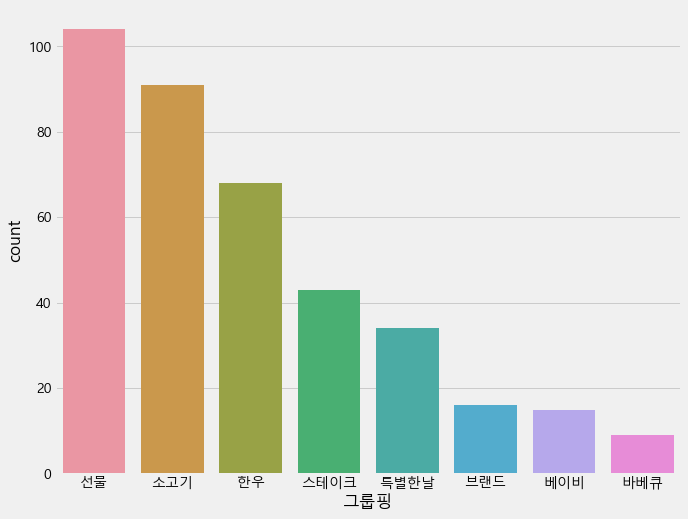

In [136]:
# 그룹별 키워드 개수
plt.figure(figsize=(10, 8))
sns.countplot(df['그룹핑'], order=df['그룹핑'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

In [137]:
df_by_group_label = df.groupby('그룹핑').sum()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
# 전환율 컬럼 추가
df_by_group_label['전환율'] = df_by_group_label['구매'] / df_by_group_label['클릭'] * 100
df_by_group_label

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,전환율
그룹핑,,,,,,,,,,
바베큐,290785,12944,220,62.81,11317,6963,1,0,0.000000,0.454545
베이비,131362,4402,111,170.93,13311,31029,20,305985,232.932659,18.018018
브랜드,423973,8649,271,346.56,5092,9155,132,4115602,970.722664,48.708487
선물,6982602,240360,2272,1014.42,214575,524466,251,28446538,407.391657,11.047535
소고기,1591447,143340,1323,873.61,92375,289477,164,2366309,148.689149,12.396070
스테이크,2029302,131499,1538,586.19,39459,225239,111,4048075,199.481152,7.217165
특별한날,708356,156620,471,168.53,32980,0,0,0,0.000000,0.000000
한우,11816717,207446,3436,716.79,95554,399517,501,22647018,191.652368,14.580908


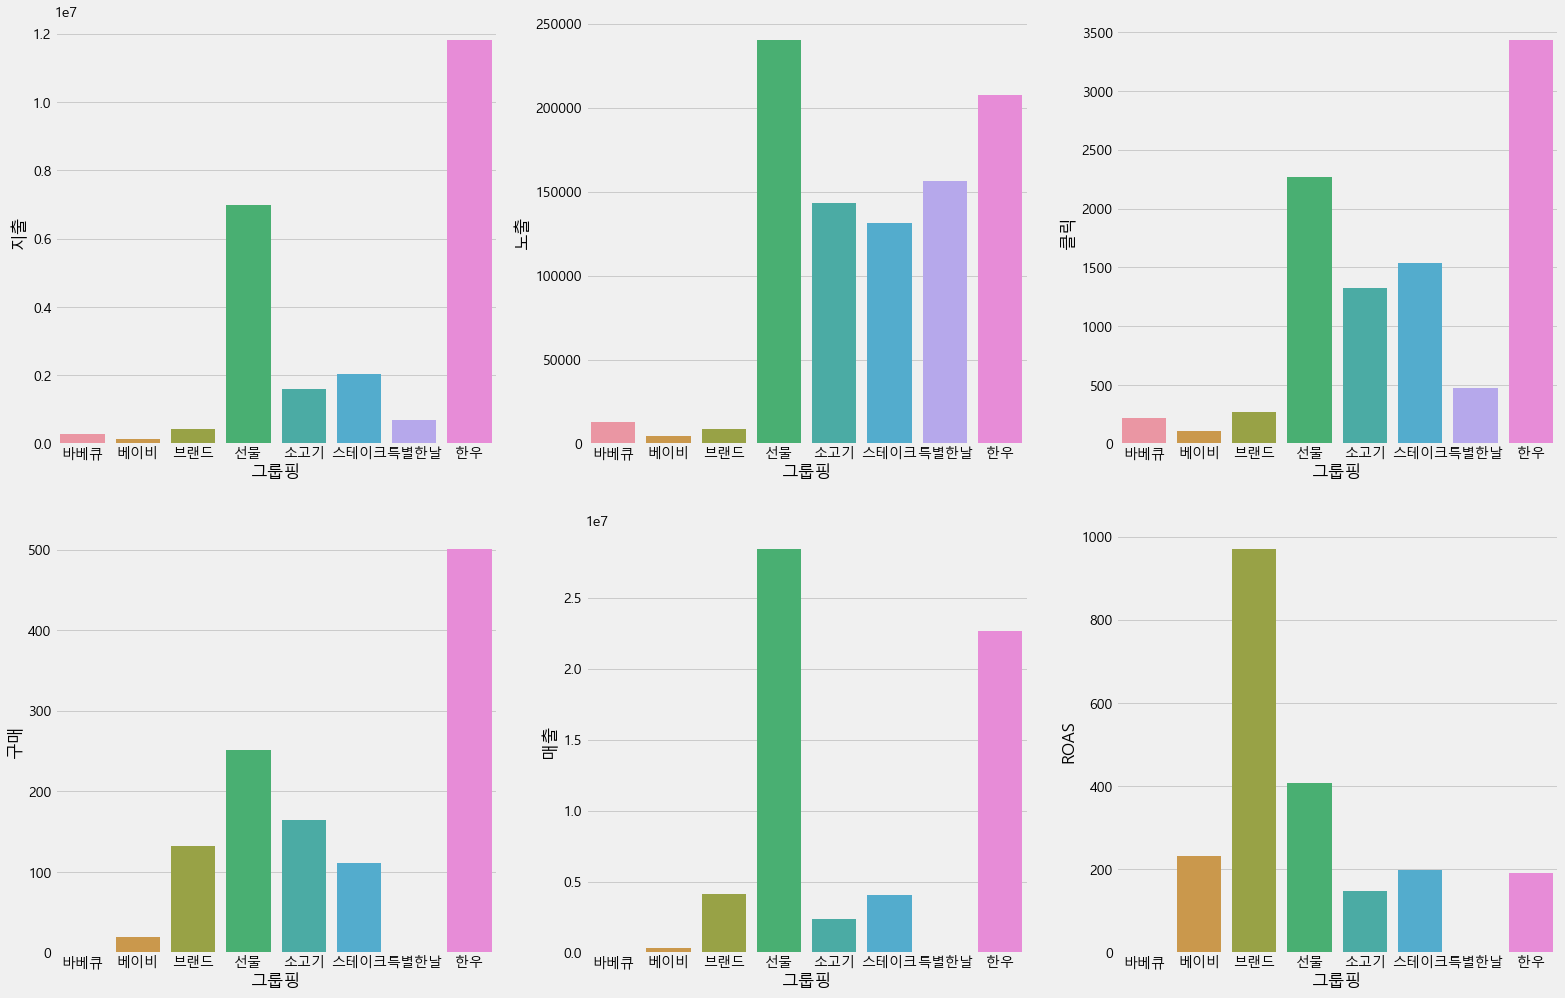

In [138]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 16))
df_by_group_label = df_by_group_label.reset_index()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
sns.barplot(x='그룹핑', y='지출', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='그룹핑', y='노출', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='그룹핑', y='클릭', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='그룹핑', y='구매', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='그룹핑', y='매출', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='그룹핑', y='ROAS', data=df_by_group_label, ax=axes[1, 2])
plt.show()

In [139]:
df_by_group_label

,그룹핑,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS,전환율
0,바베큐,290785,12944,220,62.81,11317,6963,1,0,0.000000,0.454545
1,베이비,131362,4402,111,170.93,13311,31029,20,305985,232.932659,18.018018
2,브랜드,423973,8649,271,346.56,5092,9155,132,4115602,970.722664,48.708487
3,선물,6982602,240360,2272,1014.42,214575,524466,251,28446538,407.391657,11.047535
4,소고기,1591447,143340,1323,873.61,92375,289477,164,2366309,148.689149,12.396070
5,스테이크,2029302,131499,1538,586.19,39459,225239,111,4048075,199.481152,7.217165
6,특별한날,708356,156620,471,168.53,32980,0,0,0,0.000000,0.000000
7,한우,11816717,207446,3436,716.79,95554,399517,501,22647018,191.652368,14.580908


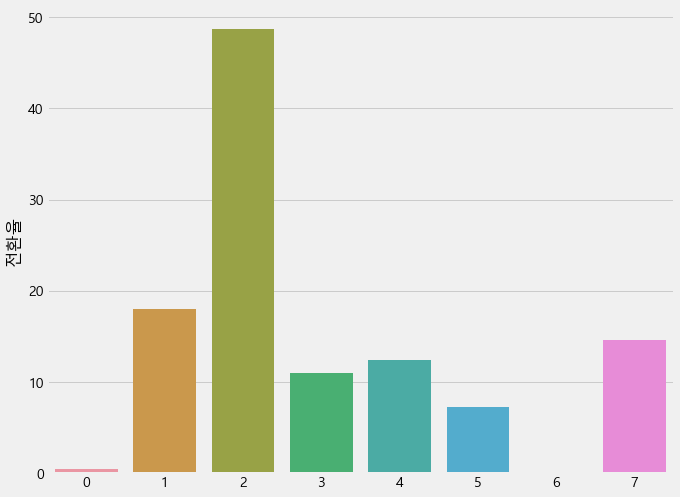

In [140]:
# 전환율
plt.figure(figsize=(10, 8))
sns.barplot(df_by_group_label.index, df_by_group_label['전환율'])
# plt.xticks(rotation=90)
plt.show()

+ 왜 브랜드가 ROAS가 높지?
+ 한우로 키워드를 그룹핑한 이유?
+ 1월이라는 특수성으로 선물 키워드 수치 높음

### 구글디스플레이 소재별

In [141]:
df_by_group_label = df2.groupby(['PC/MO', '소재 이름', '소재 크기']).sum()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
df_by_group_label

지출       노출   클릭   CTR   CPC    CPA   구매  \
PC/MO 소재 이름         소재 크기                                                   
MO    구이용           300X250  189607   842038  510  0.06   372   4309   44   
                    320X100  491352  3378198  854  0.03   575   1806  272   
                    320X50   124867   756182  196  0.03   637   1982   63   
                    336X280  144539   482446  602  0.12   240   6883   21   
      한우구이2차(고기뒤집는) 300X250       0        1    0  0.00     0      0    0   
                    320X50   190436   840228  409  0.05   466   1574  121   
      한우구이2차(샤토단면)  320X50    66523   315182  123  0.04   541   1901   35   
      한우구이2차(샤토마블링) 300X250       0        2    0  0.00     0      0    0   
PC    구이용           120X600   72246   337208   68  0.02  1062   4014   18   
                    300X250   70047   257831   43  0.02  1629   2919   24   
                    300X600   44417   173381   51  0.03   871   7403    6   
                    336X280   62596   185650   76  0.04   824  20865    3   
      세트용(구이랜딩)     336X280   10640    38240   15  0.04   709  10640    1   
                    728X90   166148   820422  166  0.02  1001   2308   72   
      한우구이2차        336X280   16320    54198   16  0.03  1020  16320    1   
                    728X90   157545   837777  155  0.02  1016   2501   63   
      한우구이2차(고기뒤집는) 300X250  141998   569490  136  0.02  1044   2958   48   
      한우구이2차(미니샤토)  300X600   86923   298258  151  0.05   576   6209   14   
      한우구이2차(샤토)    300X250   69191   198900   67  0.03  1033   2232   31   
      한우구이2차(샤토굽는)  120X600   93258   491059  122  0.02   764   2275   41   
      한우구이2차(접시에고기) 120X600  128724   500119   75  0.01  1716   1740   74   
      한우구이2차(접시위고기) 300X600   66768   219415   64  0.03  1043   5564   12   

                                   매출          ROAS  
PC/MO 소재 이름         소재 크기                            
MO    구이용           300X250   4799160   2531.109084  
                    320X100  36787652   7487.026002  
                    320X50    8185960   6555.743311  
                    336X280   2189280   1514.663862  
      한우구이2차(고기뒤집는) 300X250         0           NaN  
                    320X50   17857758   9377.301561  
      한우구이2차(샤토단면)  320X50    4494430   6756.204621  
      한우구이2차(샤토마블링) 300X250         0           NaN  
PC    구이용           120X600   2141130   2963.665808  
                    300X250   4129246   5894.964809  
                    300X600   3603100   8111.984150  
                    336X280    515500    823.535050  
      세트용(구이랜딩)     336X280    123800   1163.533835  
                    728X90   16536390   9952.807136  
      한우구이2차        336X280    197340   1209.191176  
                    728X90    9551200   6062.521819  
      한우구이2차(고기뒤집는) 300X250  11939784   8408.417020  
      한우구이2차(미니샤토)  300X600   2173000   2499.913717  
      한우구이2차(샤토)    300X250   5620990   8123.874492  
      한우구이2차(샤토굽는)  120X600   9378760  10056.788694  
      한우구이2차(접시에고기) 120X600  17762302  13798.749262  
      한우구이2차(접시위고기) 300X600   2139860   3204.918524

#### PC/MO

In [142]:
df2_gpm

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
PC/MO,,,,,,,,,
MO,1207324,6614277,2694,0.33,2831,18455,556,74314240,6155.285574
PC,1186821,4981948,1205,0.38,14308,87948,408,85812402,7230.441827


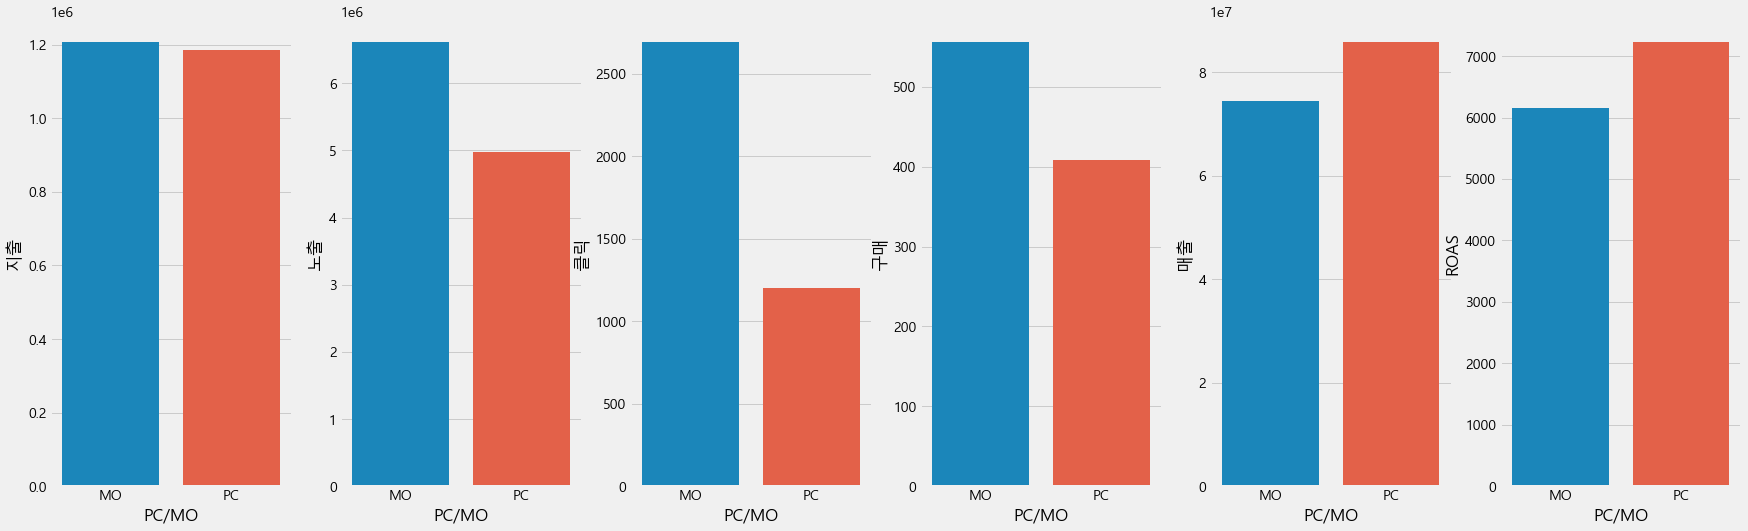

In [143]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(27, 8))
df_by_group_label = df2_gpm.reset_index()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
sns.barplot(x='PC/MO', y='지출', data=df_by_group_label, ax=axes[0])
sns.barplot(x='PC/MO', y='노출', data=df_by_group_label, ax=axes[1])
sns.barplot(x='PC/MO', y='클릭', data=df_by_group_label, ax=axes[2])
sns.barplot(x='PC/MO', y='구매', data=df_by_group_label, ax=axes[3])
sns.barplot(x='PC/MO', y='매출', data=df_by_group_label, ax=axes[4])
sns.barplot(x='PC/MO', y='ROAS', data=df_by_group_label, ax=axes[5])
plt.show()

#### 소재 이름

In [144]:
df_by_group_label = df2.groupby(['PC/MO', '소재 이름']).sum()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
df_by_group_label

지출       노출    클릭   CTR   CPC    CPA   구매        매출  \
PC/MO 소재 이름                                                                    
MO    구이용            950365  5458864  2162  0.24  1824  14980  400  51962052   
      한우구이2차(고기뒤집는)  190436   840229   409  0.05   466   1574  121  17857758   
      한우구이2차(샤토단면)    66523   315182   123  0.04   541   1901   35   4494430   
      한우구이2차(샤토마블링)       0        2     0  0.00     0      0    0         0   
PC    구이용            249306   954070   238  0.11  4386  35201   51  10388976   
      세트용(구이랜딩)      176788   858662   181  0.06  1710  12948   73  16660190   
      한우구이2차         173865   891975   171  0.05  2036  18821   64   9748540   
      한우구이2차(고기뒤집는)  141998   569490   136  0.02  1044   2958   48  11939784   
      한우구이2차(미니샤토)    86923   298258   151  0.05   576   6209   14   2173000   
      한우구이2차(샤토)      69191   198900    67  0.03  1033   2232   31   5620990   
      한우구이2차(샤토굽는)    93258   491059   122  0.02   764   2275   41   9378760   
      한우구이2차(접시에고기)  128724   500119    75  0.01  1716   1740   74  17762302   
      한우구이2차(접시위고기)   66768   219415    64  0.03  1043   5564   12   2139860   

                             ROAS  
PC/MO 소재 이름                        
MO    구이용             5467.588979  
      한우구이2차(고기뒤집는)   9377.301561  
      한우구이2차(샤토단면)    6756.204621  
      한우구이2차(샤토마블링)           NaN  
PC    구이용             4167.158432  
      세트용(구이랜딩)       9423.824015  
      한우구이2차          5606.959423  
      한우구이2차(고기뒤집는)   8408.417020  
      한우구이2차(미니샤토)    2499.913717  
      한우구이2차(샤토)      8123.874492  
      한우구이2차(샤토굽는)   10056.788694  
      한우구이2차(접시에고기)  13798.749262  
      한우구이2차(접시위고기)   3204.918524

+ 시각화에서 유의미한 데이터를 찾지 못함 표만으로도 충분히 데이터 확인 가능

#### 소재 크기

In [145]:
df_by_group_label = df2.groupby(['PC/MO', '소재 크기']).sum()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
df_by_group_label

지출       노출   클릭   CTR   CPC    CPA   구매        매출  \
PC/MO 소재 크기                                                             
MO    300X250  189607   842041  510  0.06   372   4309   44   4799160   
      320X100  491352  3378198  854  0.03   575   1806  272  36787652   
      320X50   381826  1911592  728  0.12  1644   5457  219  30538148   
      336X280  144539   482446  602  0.12   240   6883   21   2189280   
PC    120X600  294228  1328386  265  0.05  3542   8029  133  29282192   
      300X250  281236  1026221  246  0.07  3706   8109  103  21690020   
      300X600  198108   691054  266  0.11  2490  19176   32   7915960   
      336X280   89556   278088  107  0.11  2553  47825    5    836640   
      728X90   323693  1658199  321  0.04  2017   4809  135  26087590   

                      ROAS  
PC/MO 소재 크기                 
MO    300X250  2531.109084  
      320X100  7487.026002  
      320X50   7997.922614  
      336X280  1514.663862  
PC    120X600  9952.211210  
      300X250  7712.391017  
      300X600  3995.780080  
      336X280   934.208763  
      728X90   8059.361803

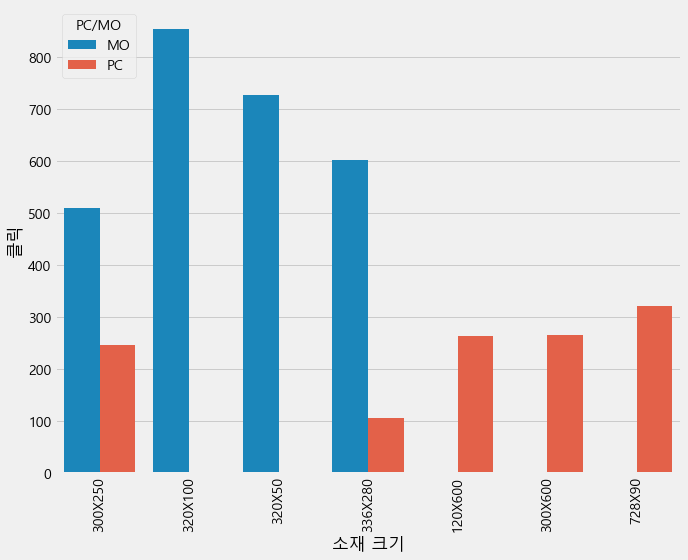

In [146]:
df_by_group_label = df2.groupby(['PC/MO', '소재 크기']).sum().reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(x='소재 크기', y='클릭', hue='PC/MO', data=df_by_group_label )
plt.xticks(rotation=90)
plt.show()

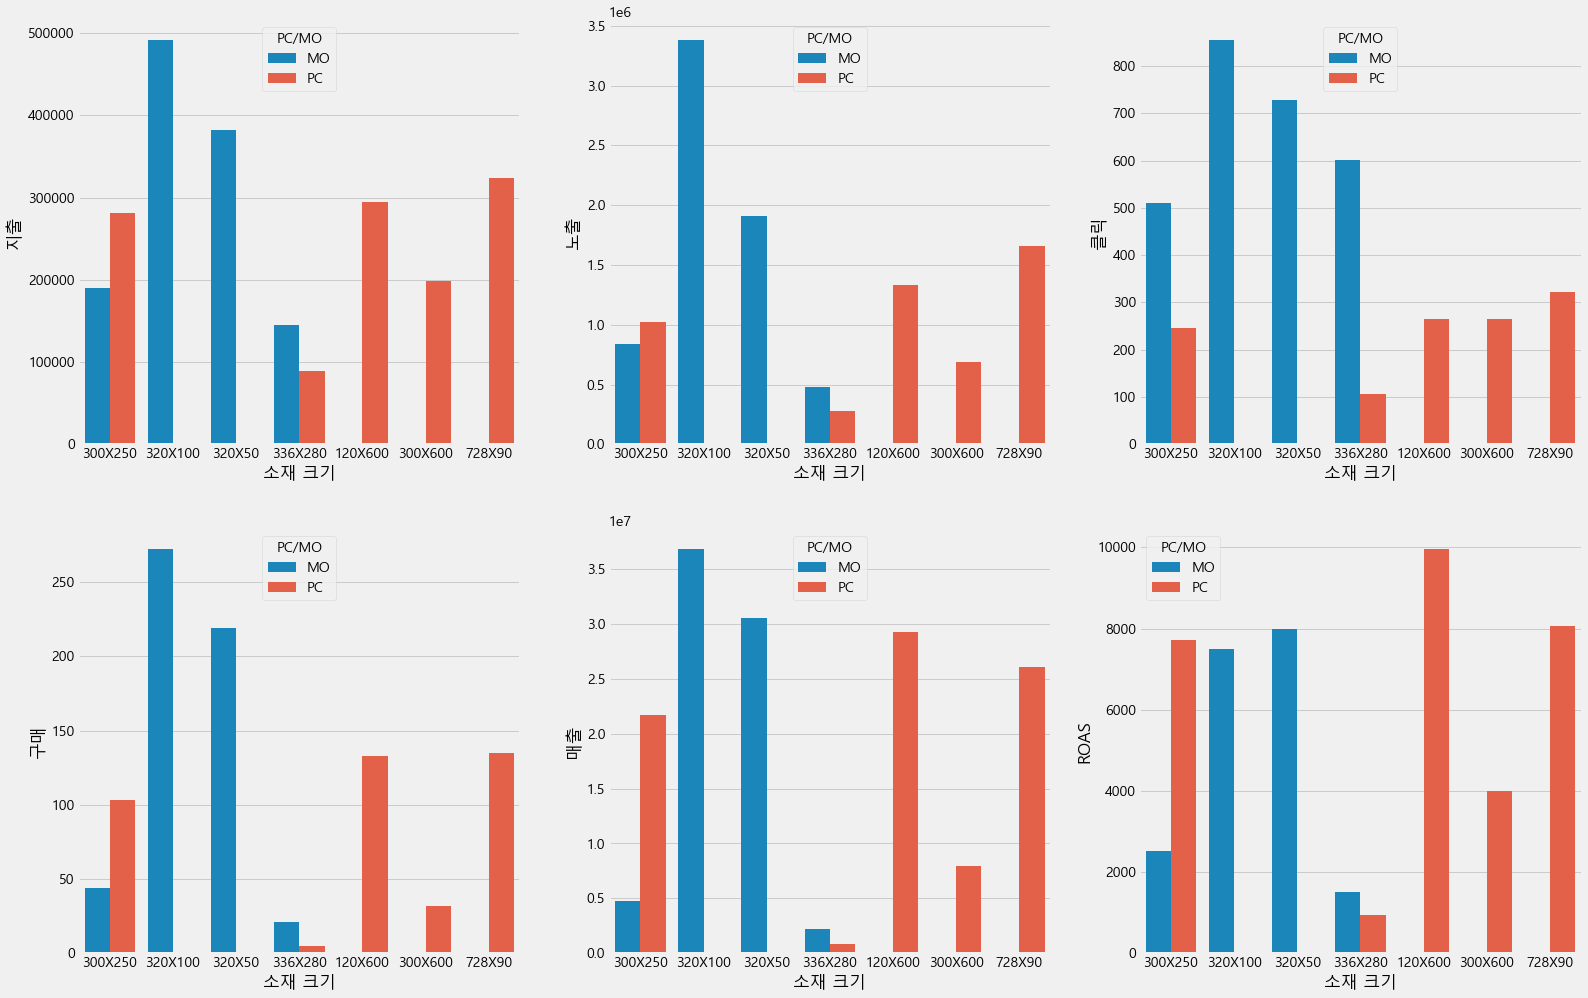

In [147]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 16))
df_by_group_label = df2.groupby(['PC/MO', '소재 크기']).sum().reset_index()
df_by_group_label['ROAS'] = (df_by_group_label['매출'] / df_by_group_label['지출']) * 100
sns.barplot(x='소재 크기', y='지출', hue='PC/MO', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='소재 크기', y='노출', hue='PC/MO', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='소재 크기', y='클릭', hue='PC/MO', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='소재 크기', y='구매', hue='PC/MO', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='소재 크기', y='매출', hue='PC/MO', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='소재 크기', y='ROAS', hue='PC/MO', data=df_by_group_label, ax=axes[1, 2])
plt.show()

### 구글애널리틱스 키워드별

In [148]:
df_by_group_label = df3.groupby('그룹핑').sum()

# 이탈율 계산
df_by_group_label['이탈율'] = df_by_group_label['이탈수'] / df_by_group_label['사용자'] * 100

# 전환율 계산
df_by_group_label['전환율'] = df_by_group_label['구매'] / df_by_group_label['세션'] * 100

df_by_group_label

,사용자,세션,이탈수,이탈율,세션당PV,구매,전환율
그룹핑,,,,,,,
바베큐,217,222,163,75.115207,17.08,0,0.000000
베이비,119,124,48,40.336134,103.18,3,2.419355
브랜드,288,331,82,28.472222,42.85,9,2.719033
선물,2434,2513,1344,55.217749,300.71,18,0.716275
소고기,1364,1418,724,53.079179,319.48,10,0.705219
스테이크,1573,1632,943,59.949142,107.63,10,0.612745
특별한날,477,483,408,85.534591,97.04,0,0.000000
한우,3527,3783,1359,38.531330,190.29,43,1.136664


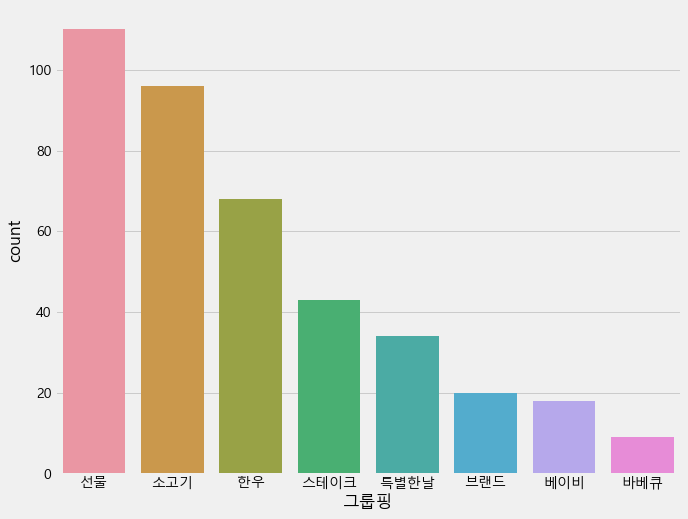

In [149]:
# 그룹별 키워드 개수
plt.figure(figsize=(10, 8))
sns.countplot(df3['그룹핑'], order=df3['그룹핑'].value_counts().index)
# plt.xticks(rotation=90)
plt.show()

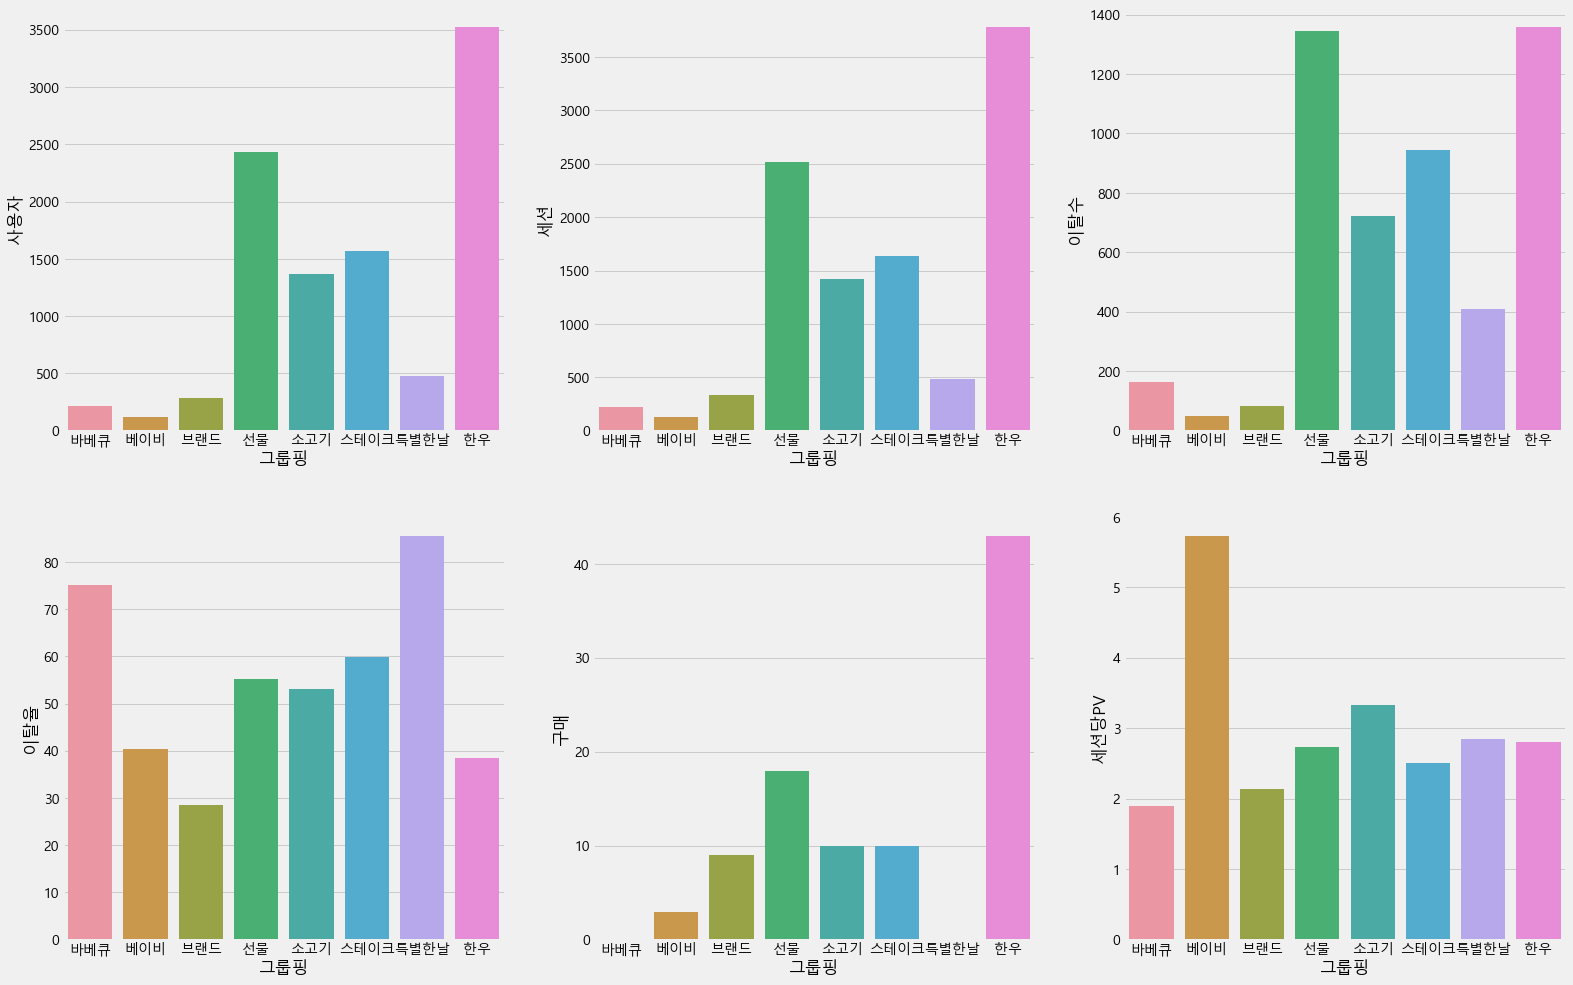

In [150]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 16))
df_by_group_label = df3.groupby('그룹핑').sum().reset_index()
df_by_group_label2 = df3.groupby('그룹핑').mean().reset_index()

# 이탈율 계산
df_by_group_label['이탈율'] = df_by_group_label['이탈수'] / df_by_group_label['사용자'] * 100
sns.barplot(x='그룹핑', y='사용자', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='그룹핑', y='세션', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='그룹핑', y='이탈수', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='그룹핑', y='이탈율', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='그룹핑', y='구매', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='그룹핑', y='세션당PV', data=df_by_group_label2, ax=axes[1, 2])
plt.show()

+ 세션당PV는 그룹의 평균으로 계산했음

### 구글애널리틱스 구글 디스플레이 소재별

In [151]:
df_by_group_label = df4.groupby(['PC/MO', '캠페인', '소재 크기']).sum()
df_by_group_label2 = df4.groupby(['PC/MO', '캠페인', '소재 크기']).mean()


# 이탈율 계산
df_by_group_label['이탈율'] = df_by_group_label['이탈수'] / df_by_group_label['사용자'] * 100

# 세선당PV
df_by_group_label['세션당PV'] = df_by_group_label2['세션당PV']

df_by_group_label

사용자   세션  이탈수         이탈율  세션당PV
PC/MO 캠페인     소재 크기                                    
MO    구이용     120X100  375  387  308   82.133333  1.670
              120X600   38   38   28   73.684211  1.640
              300X250  585  594  523   89.401709  1.500
              320X50    79   80   75   94.936709  1.140
              320X600   21   21   18   85.714286  1.330
              336X280  345  352  295   85.507246  1.540
              728X90   106  109   92   86.792453  1.390
      일상속미식   320X50   231  256  236  102.164502  1.235
PC    일상속미식   300X250  199  200  144   72.361809  1.990
              728X90   105  106   87   82.857143  1.830
      일상속미식경험 120X600   77   77   62   80.519481  1.640
      일상을특별하게 300X600  183  182  129   70.491803  2.300
      한우로즐기는  336X280   12   12    7   58.333333  1.500

#### PC/MO

In [152]:
df_by_group_label = df4.groupby('PC/MO').sum()
df_by_group_label2 = df4.groupby('PC/MO').mean()

# 이탈율, 세선당PV 수정
df_by_group_label['이탈율'] = df_by_group_label['이탈수'] / df_by_group_label['사용자'] * 100
df_by_group_label['세션당PV'] = df_by_group_label2['세션당PV']

df_by_group_label

,사용자,세션,이탈수,이탈율,세션당PV
PC/MO,,,,,
MO,1780,1837,1575,88.483146,1.408889
PC,576,577,429,74.479167,1.898750


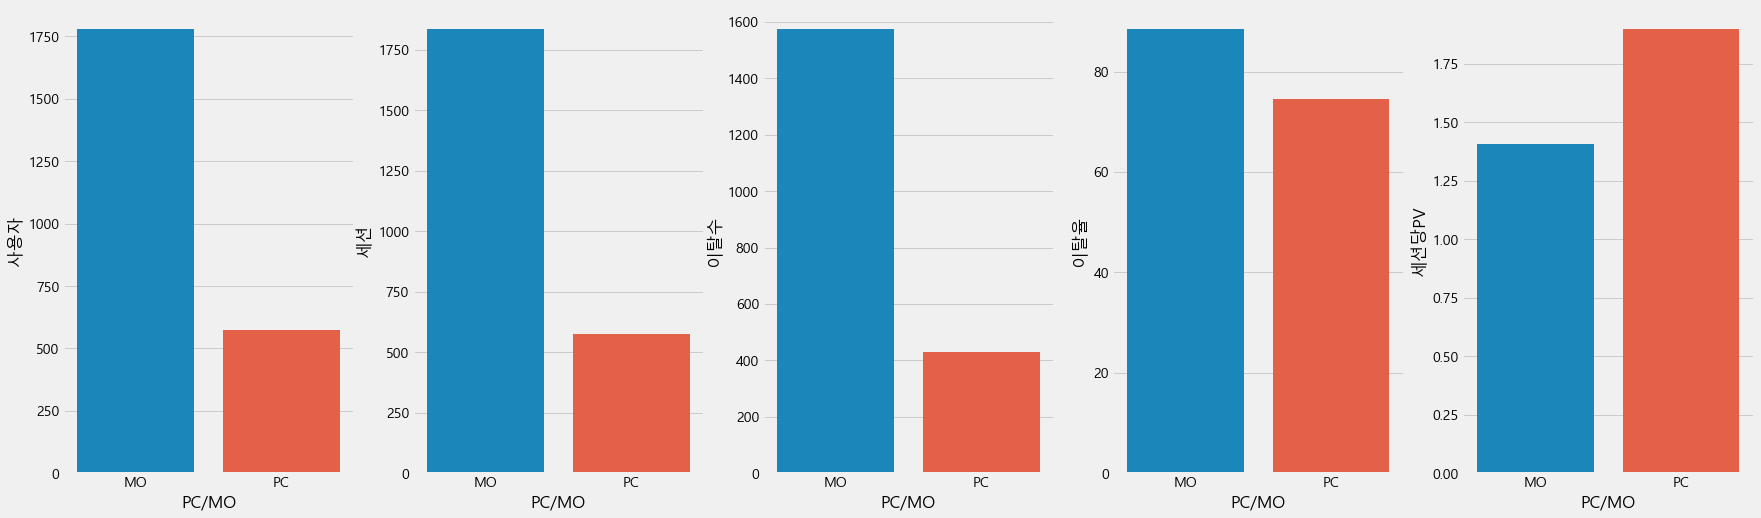

In [153]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(27, 8))
df_by_group_label = df_by_group_label.reset_index()

sns.barplot(x='PC/MO', y='사용자', data=df_by_group_label, ax=axes[0])
sns.barplot(x='PC/MO', y='세션', data=df_by_group_label, ax=axes[1])
sns.barplot(x='PC/MO', y='이탈수', data=df_by_group_label, ax=axes[2])
sns.barplot(x='PC/MO', y='이탈율', data=df_by_group_label, ax=axes[3])
sns.barplot(x='PC/MO', y='세션당PV', data=df_by_group_label, ax=axes[4])

plt.show()

#### 캠페인

In [154]:
df_by_group_label = df4.groupby(['PC/MO', '캠페인']).sum()
df_by_group_label2 = df4.groupby(['PC/MO', '캠페인']).mean()

# 이탈율, 세선당PV 수정
df_by_group_label['이탈율'] = df_by_group_label['이탈수'] / df_by_group_label['세션'] * 100
df_by_group_label['세션당PV'] = df_by_group_label2['세션당PV']

df_by_group_label

사용자    세션   이탈수        이탈율     세션당PV
PC/MO 캠페인                                           
MO    구이용      1549  1581  1339  84.693232  1.458571
      일상속미식     231   256   236  92.187500  1.235000
PC    일상속미식     304   306   231  75.490196  1.936667
      일상속미식경험    77    77    62  80.519481  1.640000
      일상을특별하게   183   182   129  70.879121  2.300000
      한우로즐기는     12    12     7  58.333333  1.500000

#### 소재 크기

In [155]:
df_by_group_label = df4.groupby(['PC/MO', '소재 크기']).sum()
df_by_group_label2 = df4.groupby(['PC/MO', '소재 크기']).mean()

# 이탈율, 세선당PV 수정
df_by_group_label['이탈율'] = df_by_group_label['이탈수'] / df_by_group_label['사용자'] * 100
df_by_group_label['세션당PV'] = df_by_group_label2['세션당PV']

df_by_group_label

사용자   세션  이탈수         이탈율     세션당PV
PC/MO 소재 크기                                       
MO    120X100  375  387  308   82.133333  1.670000
      120X600   38   38   28   73.684211  1.640000
      300X250  585  594  523   89.401709  1.500000
      320X50   310  336  311  100.322581  1.203333
      320X600   21   21   18   85.714286  1.330000
      336X280  345  352  295   85.507246  1.540000
      728X90   106  109   92   86.792453  1.390000
PC    120X600   77   77   62   80.519481  1.640000
      300X250  199  200  144   72.361809  1.990000
      300X600  183  182  129   70.491803  2.300000
      336X280   12   12    7   58.333333  1.500000
      728X90   105  106   87   82.857143  1.830000

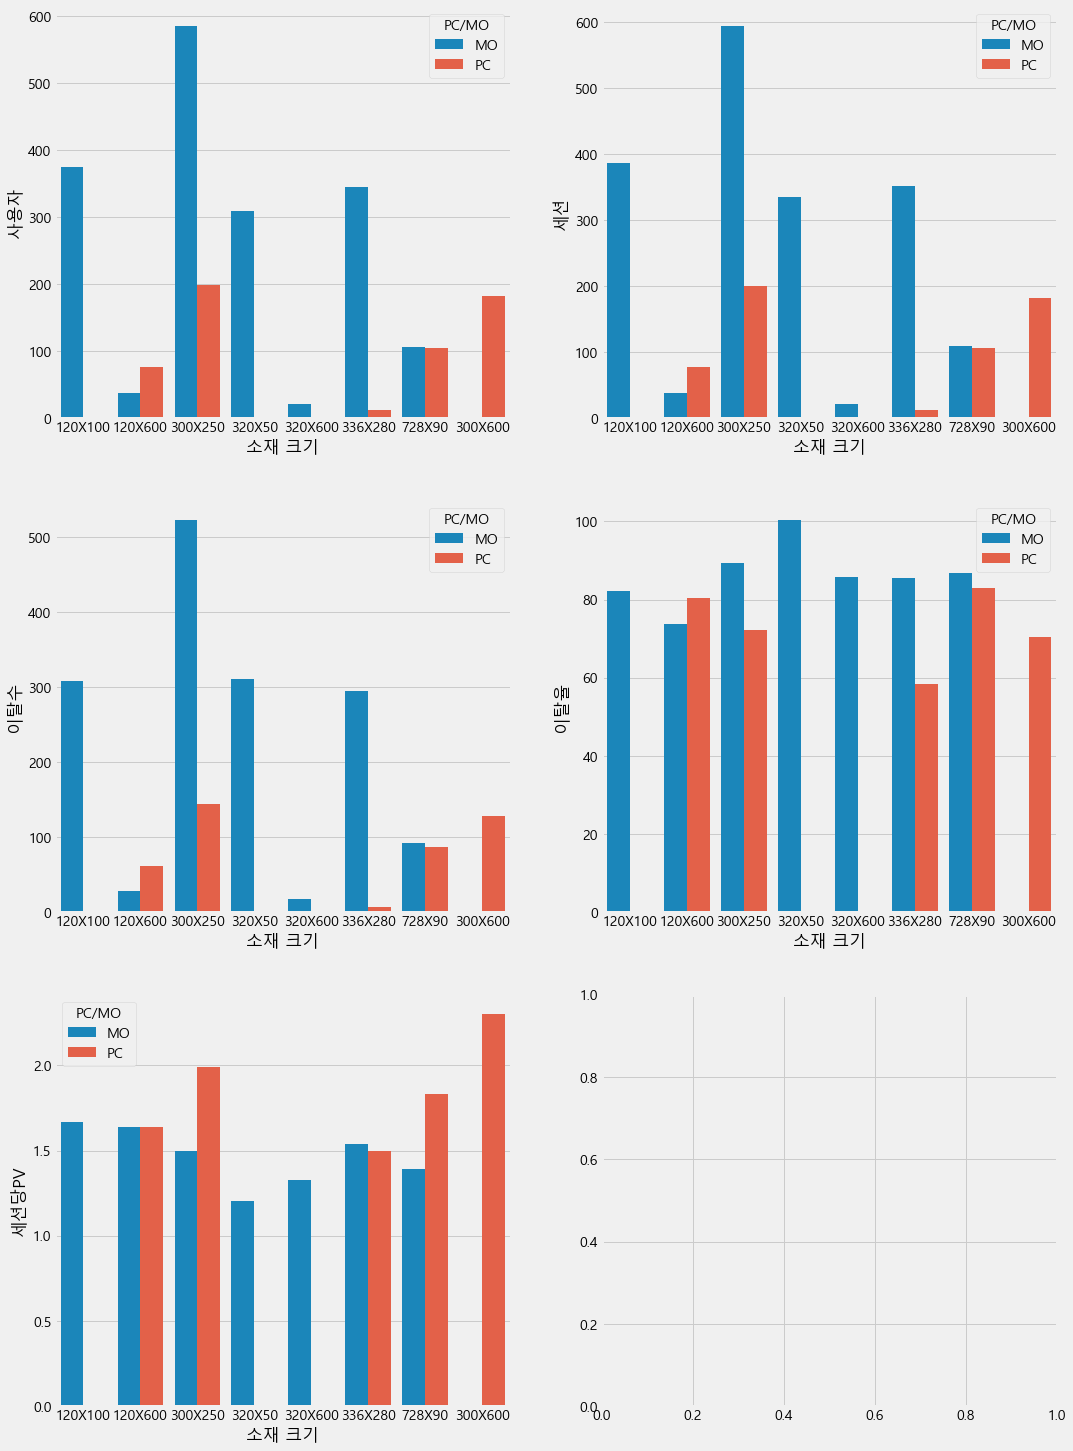

In [156]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 24))
df_by_group_label = df_by_group_label.reset_index()

sns.barplot(x='소재 크기', y='사용자', hue='PC/MO', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='소재 크기', y='세션', hue='PC/MO', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='소재 크기', y='이탈수', hue='PC/MO', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='소재 크기', y='이탈율', hue='PC/MO', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='소재 크기', y='세션당PV', hue='PC/MO', data=df_by_group_label, ax=axes[2, 0])

plt.show()

In [157]:
df.corr()

,지출,노출,클릭,CTR,CPC,CPA,구매,매출,ROAS
지출,1.000000,0.788108,0.963440,-0.065152,0.268351,0.184709,0.957547,0.712652,-0.006533
노출,0.788108,1.000000,0.861693,-0.155017,0.274352,0.365055,0.718962,0.629347,-0.013851
클릭,0.963440,0.861693,1.000000,-0.109490,0.269116,0.272029,0.921655,0.706650,-0.011323
CTR,-0.065152,-0.155017,-0.109490,1.000000,-0.248062,-0.123427,-0.062799,-0.072020,0.069682
CPC,0.268351,0.274352,0.269116,-0.248062,1.000000,0.190946,0.238143,0.269914,-0.066772
CPA,0.184709,0.365055,0.272029,-0.123427,0.190946,1.000000,0.122203,0.262171,-0.011263
구매,0.957547,0.718962,0.921655,-0.062799,0.238143,0.122203,1.000000,0.710190,0.031673
매출,0.712652,0.629347,0.706650,-0.072020,0.269914,0.262171,0.710190,1.000000,0.020869
ROAS,-0.006533,-0.013851,-0.011323,0.069682,-0.066772,-0.011263,0.031673,0.020869,1.000000
